# <p style="padding:10px;background-color:#E0F7FA;margin:0;color:#00796B;font-family:newtimeroman;font-size:150%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">Brain Stroke Analysis & Prediction</p>

<p style="text-align:justify;">
<B>Brain Stroke</B> is a critical medical condition that occurs when the blood supply to part of the brain is interrupted or reduced. This interruption can be due to:

*   **Ischemic Stroke:** A blockage in a blood vessel that prevents blood and oxygen from reaching brain tissue.
*   **Hemorrhagic Stroke:** A blood vessel in the brain ruptures and leaks, leading to brain damage.

Without oxygen, brain cells are damaged and can die rapidly, resulting in various symptoms. Once brain cells die, they generally do not regenerate, potentially causing severe and lasting physical, cognitive, and mental disabilities. Prompt medical attention to restore blood flow is crucial.

Globally, brain stroke is:

*   The **second leading cause of death**.
*   The **third leading cause of disability**.

While 80% of strokes are preventable, having a stroke significantly increases the risk of experiencing another.
</p>

<a id="1"></a>
# <p style="padding:10px;background-color:#E0F7FA;margin:0;color:#00796B;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">Importing Libraries</p>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import BernoulliNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

<a id="2"></a>
# <p style="padding:10px;background-color:#E0F7FA;margin:0;color:#00796B;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">About Dataset</p>

* **id:** Unique identifier
* **gender:** Gender of the patient (Male, Female, Other)
* **age:** Age of the patient
* **hypertension:** **0** if the patient doesn't have hypertension, **1** if the patient has hypertension
* **heart_disease:** **0** if the patient doesn't have any heart diseases, **1** if the patient has a heart disease
* **ever_married:** **Yes** if the patient is married, **No** if the patient is not married
* **work_type:** Profession of the patient (children, Govt_job, Never_worked, Private, Self-employed)
* **Residence_type:** Residence category of the patient (Rural, Urban)
* **avg_glucose_level:** Average glucose level in blood of the patient
* **bmi:** Body Mass Index of the patient
* **smoking_status:** Smoking status of the patient (formerly smoked, never smoked, smokes, Unknown). **Unknown** in **smoking_status** means that the information is unavailable for this patient
* **stroke:** **1** if the patient had a stroke or **0** if not


In [62]:
data = pd.read_csv("/content/healthcare-dataset-stroke-data.csv")

<a id="3"></a>
# <p style="padding:10px;background-color:#E0F7FA;margin:0;color:#00796B;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">Basic Exploration</p>


**Let's have a glimpse of the dataset.**

In [65]:
data.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [7]:
print(f"Dataset Information:\n")
print(data.info())

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB
None


<a id="4"></a>
# <p style="padding:10px;background-color:#E0F7FA;margin:0;color:#00796B;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">Dataset Summary</p>

In [92]:
print(f"Summary Of The Dataset :")
data.describe().style.set_properties(**{"background-color": palette_cmap[0],"color":palette[4],"border": f"1.5px {palette[4]}"})

Summary Of The Dataset :


,Age,BMI,Average Glucose Level
count,4908.000000,4908.000000,4908.000000
mean,42.857579,28.894560,105.297402
std,22.577004,7.854320,44.425550
min,0.000000,10.300000,55.120000
25%,25.000000,23.500000,77.067500
50%,44.000000,28.100000,91.680000
75%,60.000000,33.100000,113.495000
max,82.000000,97.600000,271.740000


In [93]:
data.describe(include=object).T.style.set_properties(**{"background-color": palette_cmap[0],"color":palette[4],"border": f"1.5px {palette[4]}"})

,count,unique,top,freq
Gender,4908,2,Female,2897
Marital Status,4908,2,Married,3204
Occupation Type,4908,5,Private Job,2810
Residence Type,4908,2,Urban,2490
Smoking Status,4908,4,Never Smoked,1852
Hypertension,4908,2,No,4457
Heart Disease,4908,2,No,4665
Stroke,4908,2,No,4699


In [58]:
dup = data[data.duplicated()].shape[0]
print(f"There is {dup} duplicate entry among {data.shape[0]} entries in this dataset.")

data.drop_duplicates(keep='first',inplace=True)
print(f"After removing duplicate entries there are {data.shape[0]} entries in this dataset.")

There is 0 duplicate entry among 4908 entries in this dataset.
After removing duplicate entries there are 4908 entries in this dataset.


In [95]:
print(f"Null values of the Dataset :")
data.isna().sum().to_frame().T.style.set_properties(**{"background-color": palette_cmap[0],"color":palette[4],"border": f"1.5px {palette[4]}"})

Null values of the Dataset :


,Age,Gender,Marital Status,BMI,Occupation Type,Residence Type,Smoking Status,Hypertension,Heart Disease,Average Glucose Level,Stroke
0,0,0,0,0,0,0,0,0,0,0,0


**Insights:**

* There are missing values in **bmi**. We will drop the rows that have missing bmi values.
* There is no duplicate values in this dataset.
* We will encode the categorical features into numerical form later.

<a id="5"></a>
# <p style="padding:10px;background-color:#E0F7FA;margin:0;color:#00796B;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">Data Preprocessing</p>

In [88]:
data.dropna(axis = 0, inplace = True)
print(f"After dropping null values, the shape of the Dataset is {data.shape}")
print(f"After dropping null values, null values of the Dataset :")
data.isna().sum().to_frame().T.style.set_properties(**{"background-color": palette_cmap[0],"color":palette[4],"border": f"1.5px {palette[4]}"})

After dropping null values, the shape of the Dataset is (4909, 12)
After dropping null values, null values of the Dataset :


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,0,0,0,0,0,0,0,0,0,0,0,0


In [89]:
data["age"] = data["age"].astype("int")
data = data[data["gender"] != "Other"]
data["hypertension"].replace({0:"No", 1:"Yes"}, inplace = True)
data["heart_disease"].replace({0:"No", 1:"Yes"}, inplace = True)
data["stroke"].replace({0:"No", 1:"Yes"}, inplace = True)
data["ever_married"].replace({"No":"Unmarried", "Yes":"Married"}, inplace = True)
data["work_type"].replace({"Self-employed":"Self Employed","children":"Children", "Govt_job":"Government Job", "Private":"Private Job", "Never_worked":"Unemployed"}, inplace = True)
data["smoking_status"].replace({"never smoked":"Never Smoked","formerly smoked":"Formerly Smoked", "smokes":"Smokes"}, inplace = True)
data.rename(columns={"gender": "Gender","age": "Age","hypertension":"Hypertension","heart_disease":"Heart Disease","ever_married":"Marital Status","work_type":"Occupation Type","Residence_type":"Residence Type","avg_glucose_level": "Average Glucose Level","bmi":"BMI","smoking_status":"Smoking Status","stroke":"Stroke"}, inplace = True)
data = data[["Age","Gender","Marital Status","BMI","Occupation Type","Residence Type","Smoking Status","Hypertension","Heart Disease","Average Glucose Level","Stroke"]]

print("After preprocessing, let's have a glimpse of the final dataset :")
data.head().style.set_properties(**{"background-color": palette_cmap[0],"color":palette[4],"border": f"1.5px {palette[4]}"})

After preprocessing, let's have a glimpse of the final dataset :


,Age,Gender,Marital Status,BMI,Occupation Type,Residence Type,Smoking Status,Hypertension,Heart Disease,Average Glucose Level,Stroke
0,67,Male,Married,36.600000,Private Job,Urban,Formerly Smoked,No,Yes,228.690000,Yes
2,80,Male,Married,32.500000,Private Job,Rural,Never Smoked,No,Yes,105.920000,Yes
3,49,Female,Married,34.400000,Private Job,Urban,Smokes,No,No,171.230000,Yes
4,79,Female,Married,24.000000,Self Employed,Rural,Never Smoked,Yes,No,174.120000,Yes
5,81,Male,Married,29.000000,Private Job,Urban,Formerly Smoked,No,No,186.210000,Yes


In [90]:
print(f"After preprocessing, let's have a look on the summary of the dataset :")
data.describe().T.style.set_properties(**{"background-color": palette_cmap[0],"color":palette[4],"border": f"1.5px {palette[4]}"})

After preprocessing, let's have a look on the summary of the dataset :


,count,mean,std,min,25%,50%,75%,max
Age,4908.000000,42.857579,22.577004,0.000000,25.000000,44.000000,60.000000,82.000000
BMI,4908.000000,28.894560,7.854320,10.300000,23.500000,28.100000,33.100000,97.600000
Average Glucose Level,4908.000000,105.297402,44.425550,55.120000,77.067500,91.680000,113.495000,271.740000


In [91]:
data.describe(include=object).T.style.set_properties(**{"background-color": palette_cmap[0],"color":palette[4],"border": f"1.5px {palette[4]}"})

,count,unique,top,freq
Gender,4908,2,Female,2897
Marital Status,4908,2,Married,3204
Occupation Type,4908,5,Private Job,2810
Residence Type,4908,2,Urban,2490
Smoking Status,4908,4,Never Smoked,1852
Hypertension,4908,2,No,4457
Heart Disease,4908,2,No,4665
Stroke,4908,2,No,4699


<a id="6"></a>
# <p style="padding:10px;background-color:#E0F7FA;margin:0;color:#00796B;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">Custom Palette For Visualization</p>

In [ ]:
sns.set_style("white")
sns.set(rc={"axes.facecolor":"#E0F7FA","figure.facecolor":"#E0F7FA","grid.color":"#B2EBF2"})
sns.set_context("poster",font_scale = .7)

# Health-related color palette
palette = ["#00BFA5","#80CBC4","#4DB6AC","#26A69A","#00796B"]
palette_cmap = ["#B2EBF2","#80DEEA","#4DD0E1","#26C6DA","#00BCD4"]


<a id="7"></a>
# <p style="padding:10px;background-color:#E0F7FA;margin:0;color:#00796B;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">Stroke Patient's Age</p>

Let's have a look on the distribution of stroke patient's age :


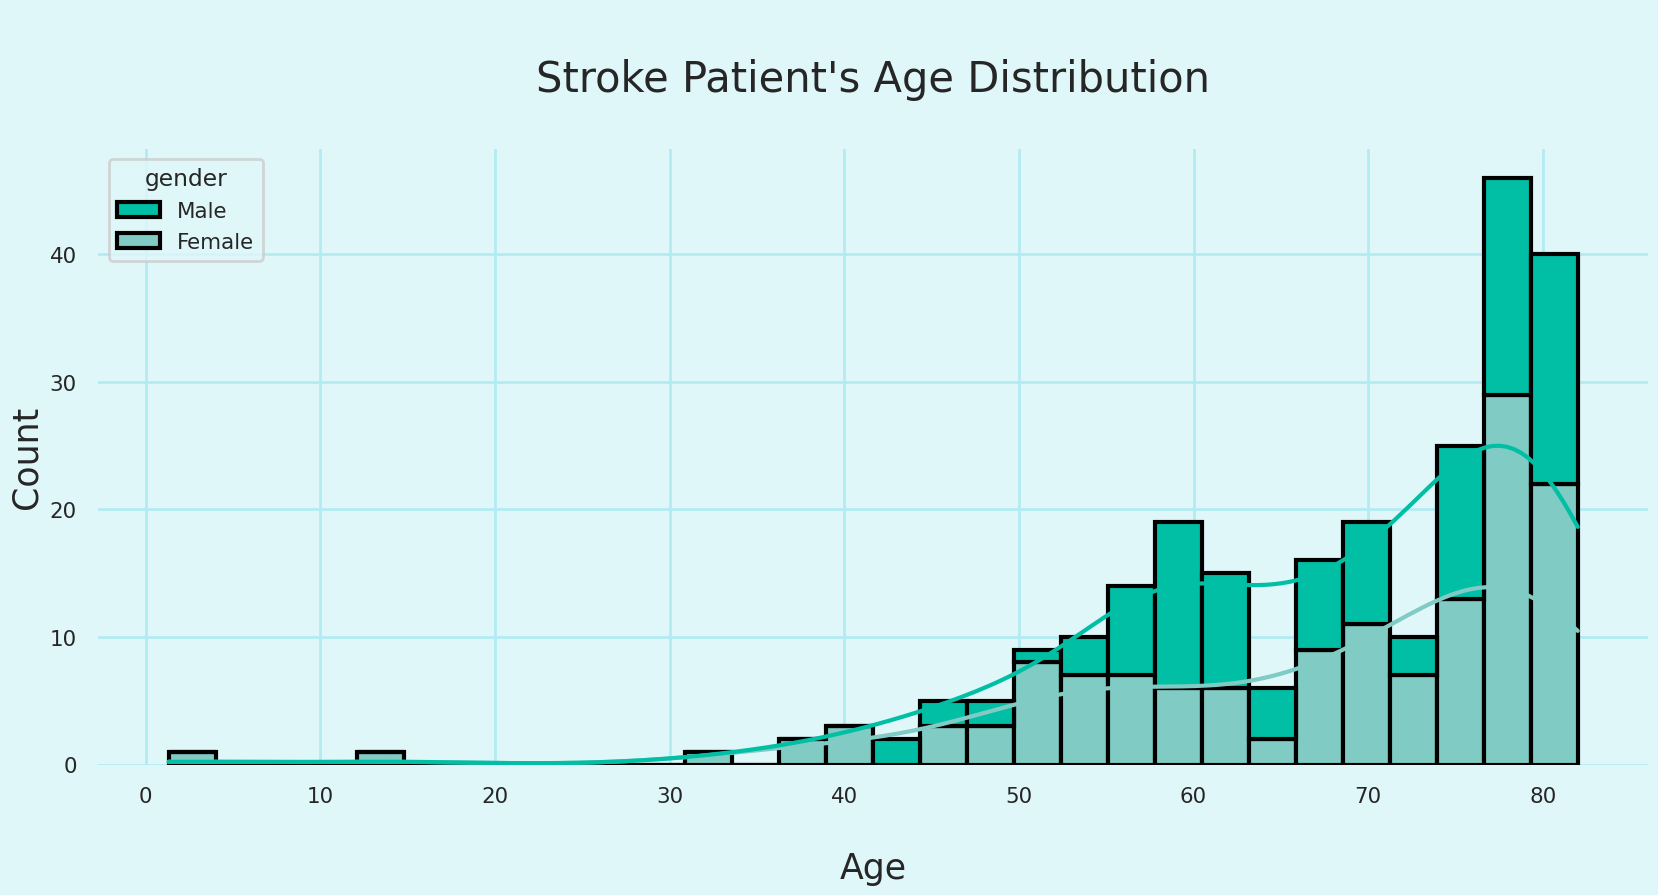

In [66]:
print(f"Let's have a look on the distribution of stroke patient's age :")
plt.subplots(figsize=(20, 8))
p = sns.histplot(data=data[data["stroke"] == 1],x="age",hue="gender",multiple="stack",palette=palette[0:2],kde=True,bins=30,alpha=1,fill=True,edgecolor="black",linewidth=3)
p.axes.lines[0].set_color(palette[1])
p.axes.lines[1].set_color(palette[0])
p.axes.set_title("\nStroke Patient's Age Distribution\n",fontsize=30)
p.set_ylabel("Count",fontsize=25)
p.set_xlabel("\nAge",fontsize=25)
p.set_yscale("linear")
sns.despine(left=True, bottom=True)

plt.show()

**Insights:**

* We can see the stroke patient's age distribution is left skewed. Most of the patients  fall in between **60 years** to **82 years**.
* Also there are some young and children female stroke patients too.

Let's have a look on the distribution of genderwise stroke patient's age :


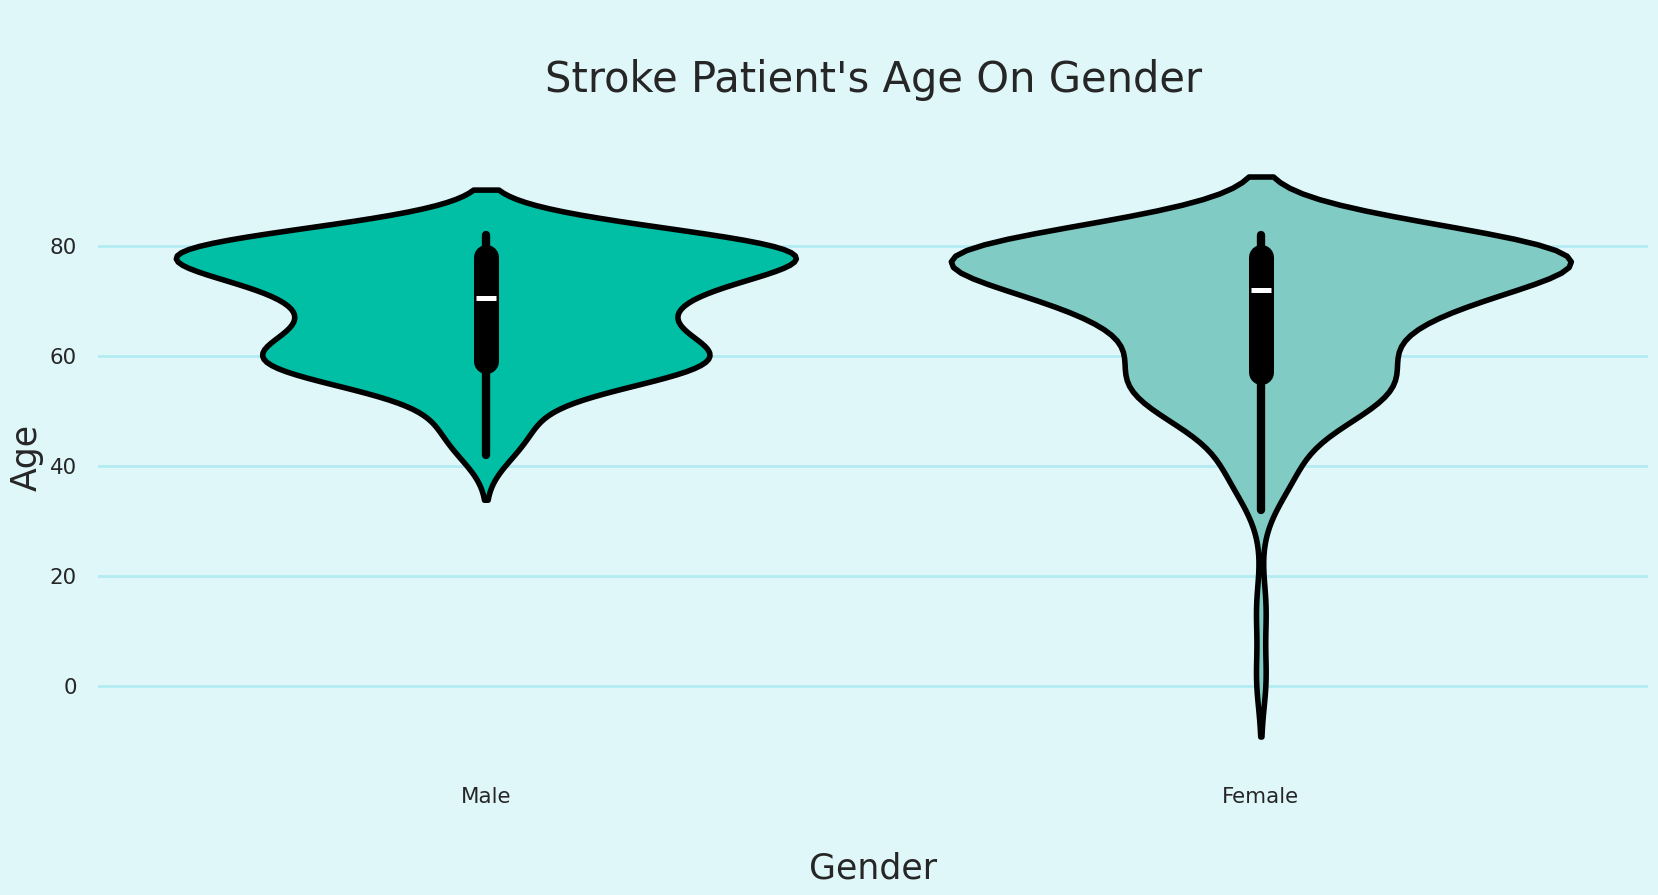

In [67]:
print("Let's have a look on the distribution of genderwise stroke patient's age :")
plt.subplots(figsize=(20, 8))

# Ensure order is based on filtered data
gender_order_age = data[data["stroke"] == 1]["gender"].value_counts(ascending=True).index
p=sns.violinplot(data=data[data["stroke"] == 1],x="gender",y="age",order=gender_order_age,palette=palette[0:2],saturation=1,linewidth=4,edgecolor="black")
p.axes.set_title("\nStroke Patient's Age On Gender\n",fontsize=30)
p.axes.set_xlabel("\nGender",fontsize=25)
p.axes.set_ylabel("Age",fontsize=25)

sns.despine(left=True, bottom=True)
plt.show()

**Insights:**

* Most of the **Male** patients fall in between **55 years** to **82 years**
* Most of the **Female** patients fall in between **48 years** to **82 years**


<a id="8"></a>
# <p style="padding:10px;background-color:#E0F7FA;margin:0;color:#00796B;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">Stroke Patient's Gender</p>

Let's have a look on the distribution of stroke patient's gender :


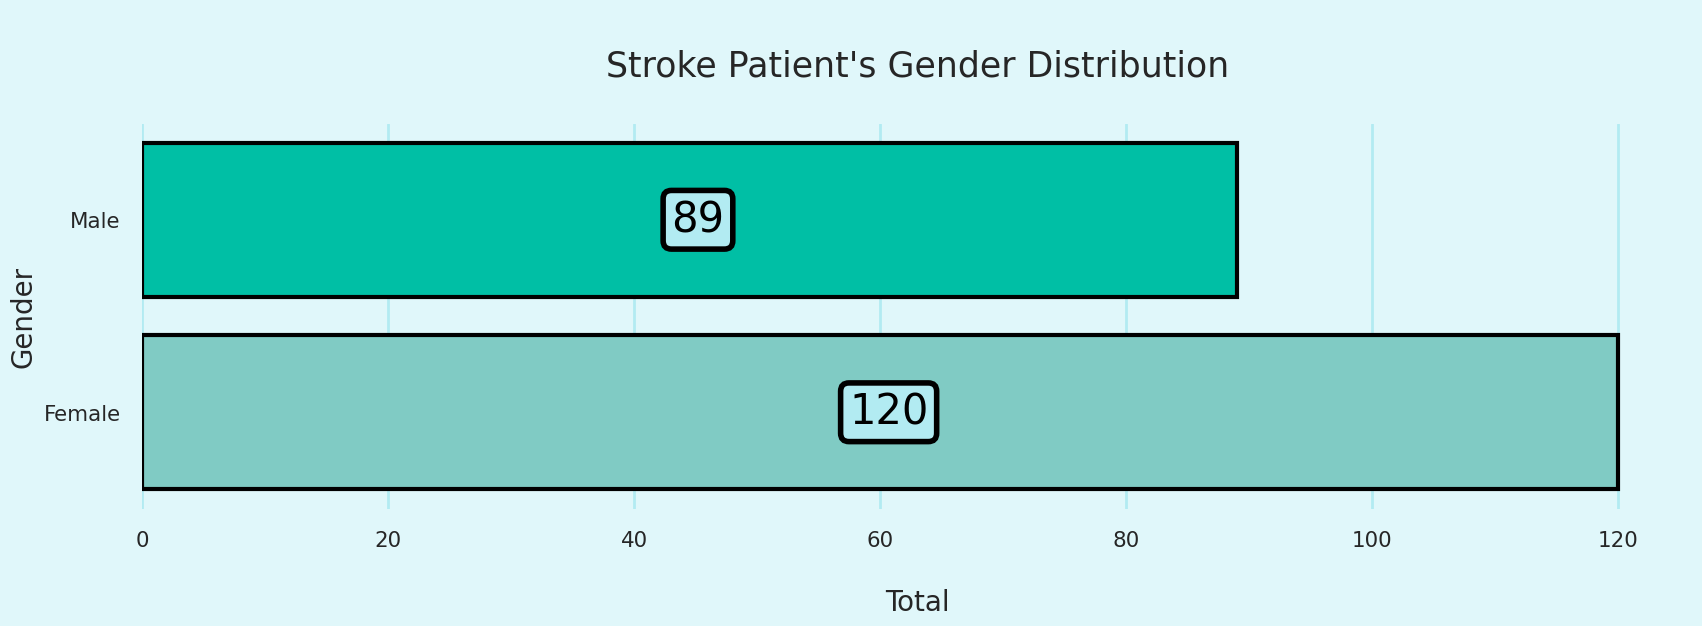

In [103]:
print(f"Let's have a look on the distribution of stroke patient's gender :")
plt.subplots(figsize=(20, 5))

# Filter for stroke patients and get value counts for 'Gender'
gender_counts = data[data["Stroke"] == "Yes"]["Gender"].value_counts(ascending=True)
p=sns.barplot(y=gender_counts.index, x=gender_counts.values, palette=palette[0:2], saturation=1, edgecolor = "black", linewidth = 3)
p.axes.set_title("\nStroke Patient's Gender Distribution\n",fontsize=25)
p.axes.set_ylabel("Gender",fontsize=20)
p.axes.set_xlabel("\nTotal",fontsize=20)
p.axes.set_yticklabels(p.get_yticklabels(),rotation = 0)
for container in p.containers:
    p.bar_label(container,label_type="center",padding=6,size=30,color="black",rotation=0,
    bbox={"boxstyle": "round", "pad": 0.2, "facecolor": palette_cmap[0], "edgecolor": "black", "linewidth" : 4, "alpha": 1})

sns.despine(left=True, bottom=True)
plt.show()

Let's have a look on the stroke patient's gender :


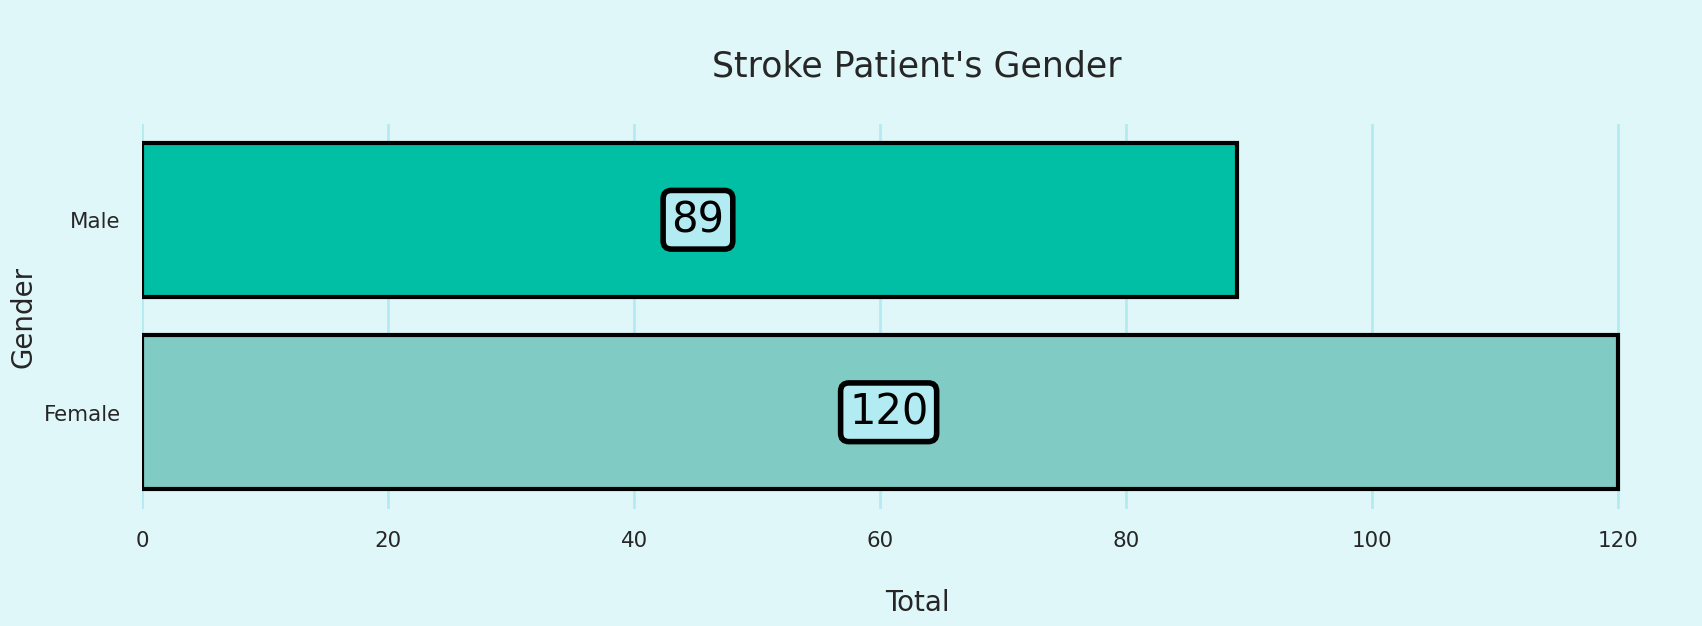

In [110]:
print("Let's have a look on the stroke patient's gender :")
plt.subplots(figsize=(20, 5))

# Filter for stroke patients and get value counts for 'Gender'
gender_counts = data[data["Stroke"] == "Yes"]["Gender"].value_counts(ascending=True)
p=sns.barplot(y=gender_counts.index, x=gender_counts.values, palette=palette[0:2], saturation=1, edgecolor = "black", linewidth = 3)
# p.axes.set_yscale("symlog")
p.axes.set_title("\nStroke Patient's Gender\n",fontsize=25)
p.axes.set_ylabel("Gender",fontsize=20)
p.axes.set_xlabel("\nTotal",fontsize=20)
p.axes.set_yticklabels(p.get_yticklabels(),rotation = 0)
for container in p.containers:
    p.bar_label(container,label_type="center",padding=6,size=30,color="black",rotation=0,
    bbox={"boxstyle": "round", "pad": 0.2, "facecolor": palette_cmap[0], "edgecolor": "black", "linewidth" : 4, "alpha": 1})

sns.despine(left=True, bottom=True)
plt.show()

**Insights:**

* Most of the stroke patients are **Female** with a ratio of **57.42%** followed by **Male** with a ratio of **42.58%**


<a id="9"></a>
# <p style="padding:10px;background-color:#E0F7FA;margin:0;color:#00796B;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">Stroke Patient's Smoking Status</p>

Let's have a look on the distribution of stroke patient's smoking status :


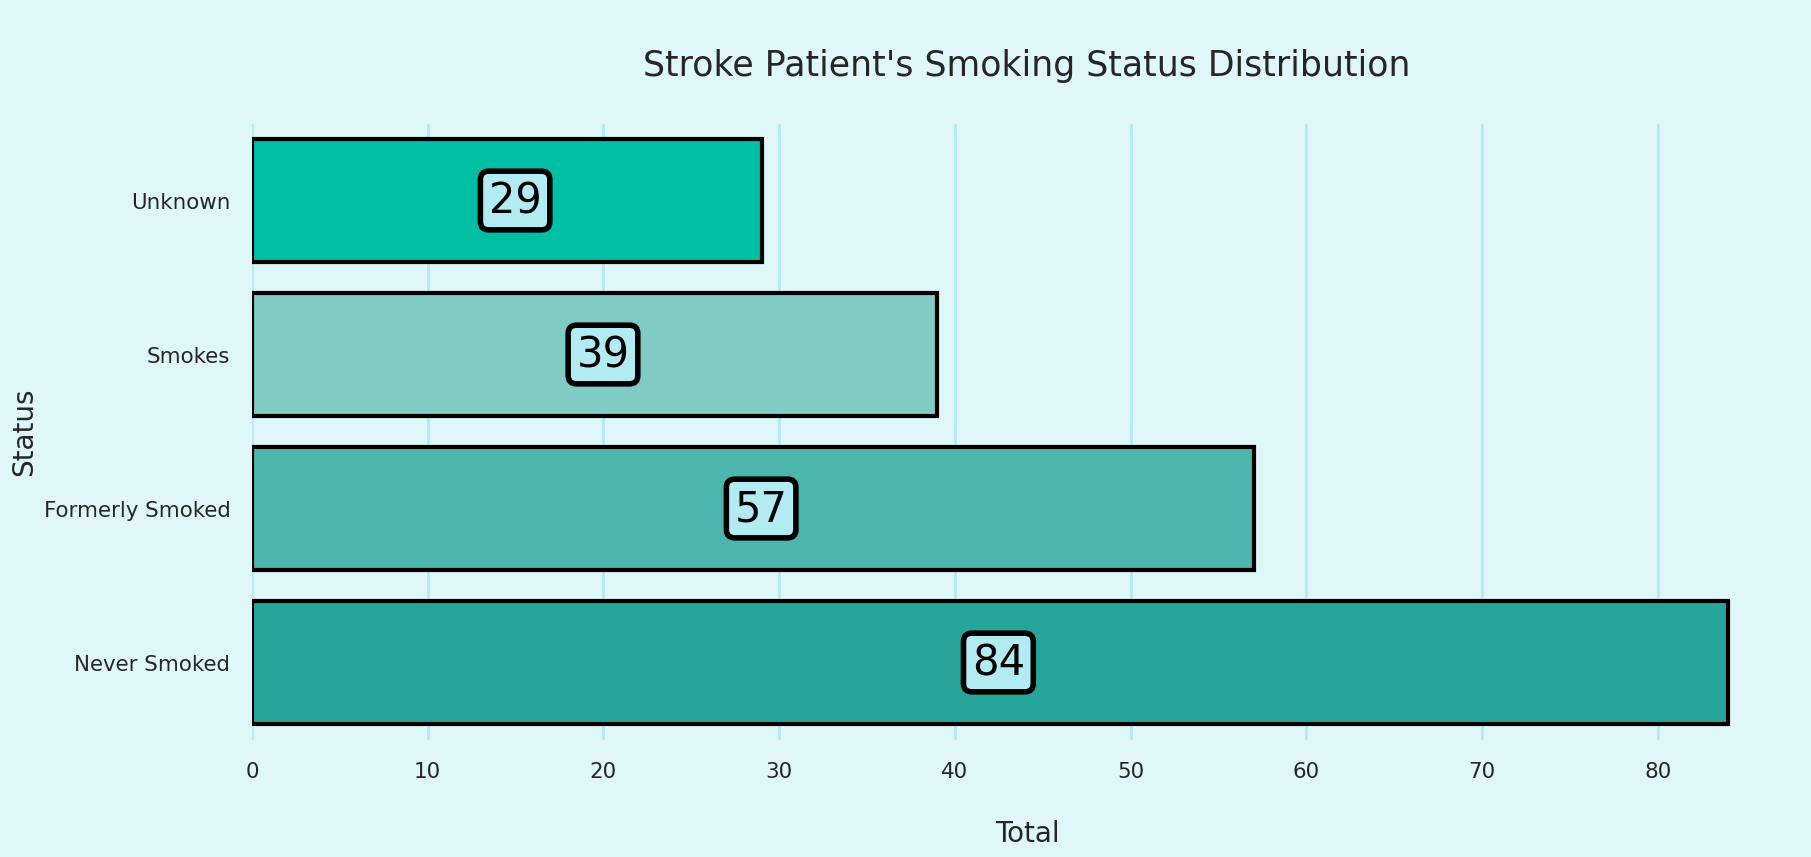

In [104]:
print(f"Let's have a look on the distribution of stroke patient's smoking status :")
plt.subplots(figsize=(20, 8))

# Filter for stroke patients and get value counts for 'Smoking Status'
smoking_counts = data[data["Stroke"] == "Yes"]["Smoking Status"].value_counts(ascending=True)
p=sns.barplot(y=smoking_counts.index, x=smoking_counts.values, palette=palette[0:4], saturation=1, edgecolor = "black", linewidth = 3)
p.axes.set_title("\nStroke Patient's Smoking Status Distribution\n",fontsize=25)
p.axes.set_ylabel("Status",fontsize=20)
p.axes.set_xlabel("\nTotal",fontsize=20)
p.axes.set_yticklabels(p.get_yticklabels(),rotation = 0)
for container in p.containers:
    p.bar_label(container,label_type="center",padding=6,size=30,color="black",rotation=0,
    bbox={"boxstyle": "round", "pad": 0.2, "facecolor": palette_cmap[0], "edgecolor": "black", "linewidth" : 4, "alpha": 1})

sns.despine(left=True, bottom=True)
plt.show()

Let's have a look on the stroke patient's smoking status :


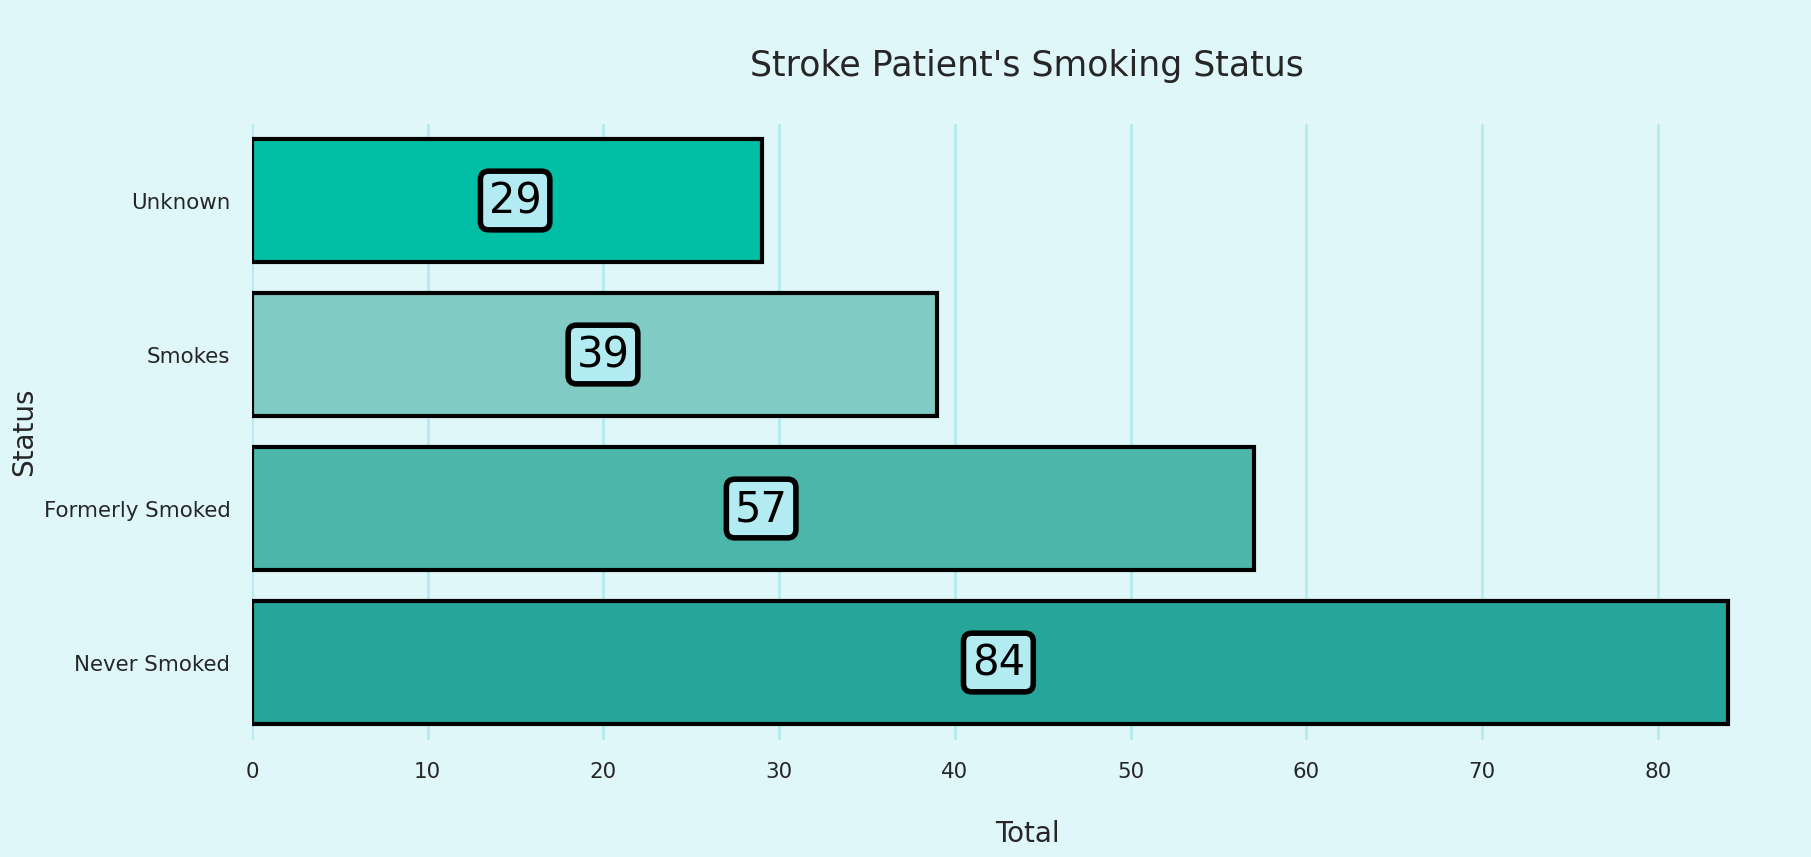

In [111]:
print("Let's have a look on the stroke patient's smoking status :")
plt.subplots(figsize=(20, 8))

# Filter for stroke patients and get value counts for 'Smoking Status'
smoking_counts = data[data["Stroke"] == "Yes"]["Smoking Status"].value_counts(ascending=True)
p=sns.barplot(y=smoking_counts.index, x=smoking_counts.values, palette=palette[0:4], saturation=1, edgecolor = "black", linewidth = 3)
# p.axes.set_yscale("symlog")
p.axes.set_title("\nStroke Patient's Smoking Status\n",fontsize=25)
p.axes.set_ylabel("Status",fontsize=20)
p.axes.set_xlabel("\nTotal",fontsize=20)
p.axes.set_yticklabels(p.get_yticklabels(),rotation = 0)
for container in p.containers:
    p.bar_label(container,label_type="center",padding=6,size=30,color="black",rotation=0,
    bbox={"boxstyle": "round", "pad": 0.2, "facecolor": palette_cmap[0], "edgecolor": "black", "linewidth" : 4, "alpha": 1})

sns.despine(left=True, bottom=True)
plt.show()

**Insights:**

* Most of the stroke patients have **Never Smoked** with a ratio of **40.19%**
* Some of the stroke patients have **Smoked Previuosly** with a ratio of **27.27%**
* For some patients, the smoking status is unknown

<a id="10"></a>
# <p style="padding:10px;background-color:#E0F7FA;margin:0;color:#00796B;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">Stroke Patient's Marital Status</p>

Let's have a look on the distribution of stroke patient's marital status :


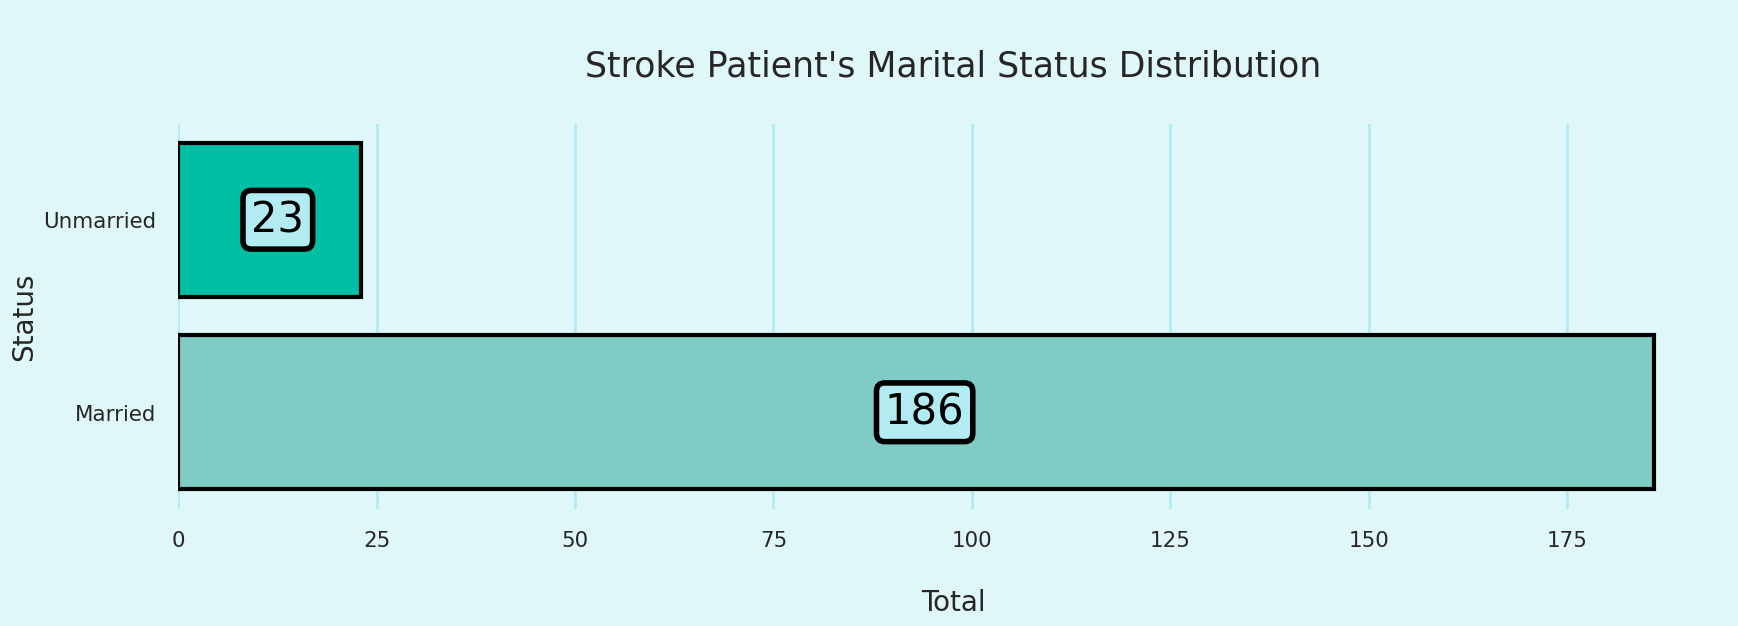

In [105]:
print(f"Let's have a look on the distribution of stroke patient's marital status :")
plt.subplots(figsize=(20, 5))

# Filter for stroke patients and get value counts for 'Marital Status'
marital_counts = data[data["Stroke"] == "Yes"]["Marital Status"].value_counts(ascending=True)
p=sns.barplot(y=marital_counts.index, x=marital_counts.values, palette=palette[0:2], saturation=1, edgecolor = "black", linewidth = 3)
p.axes.set_title("\nStroke Patient's Marital Status Distribution\n",fontsize=25)
p.axes.set_ylabel("Status",fontsize=20)
p.axes.set_xlabel("\nTotal",fontsize=20)
p.axes.set_yticklabels(p.get_yticklabels(),rotation = 0)
for container in p.containers:
    p.bar_label(container,label_type="center",padding=6,size=30,color="black",rotation=0,
    bbox={"boxstyle": "round", "pad": 0.2, "facecolor": palette_cmap[0], "edgecolor": "black", "linewidth" : 4, "alpha": 1})

sns.despine(left=True, bottom=True)
plt.show()

Let's have a look on the stroke patient's marital status :


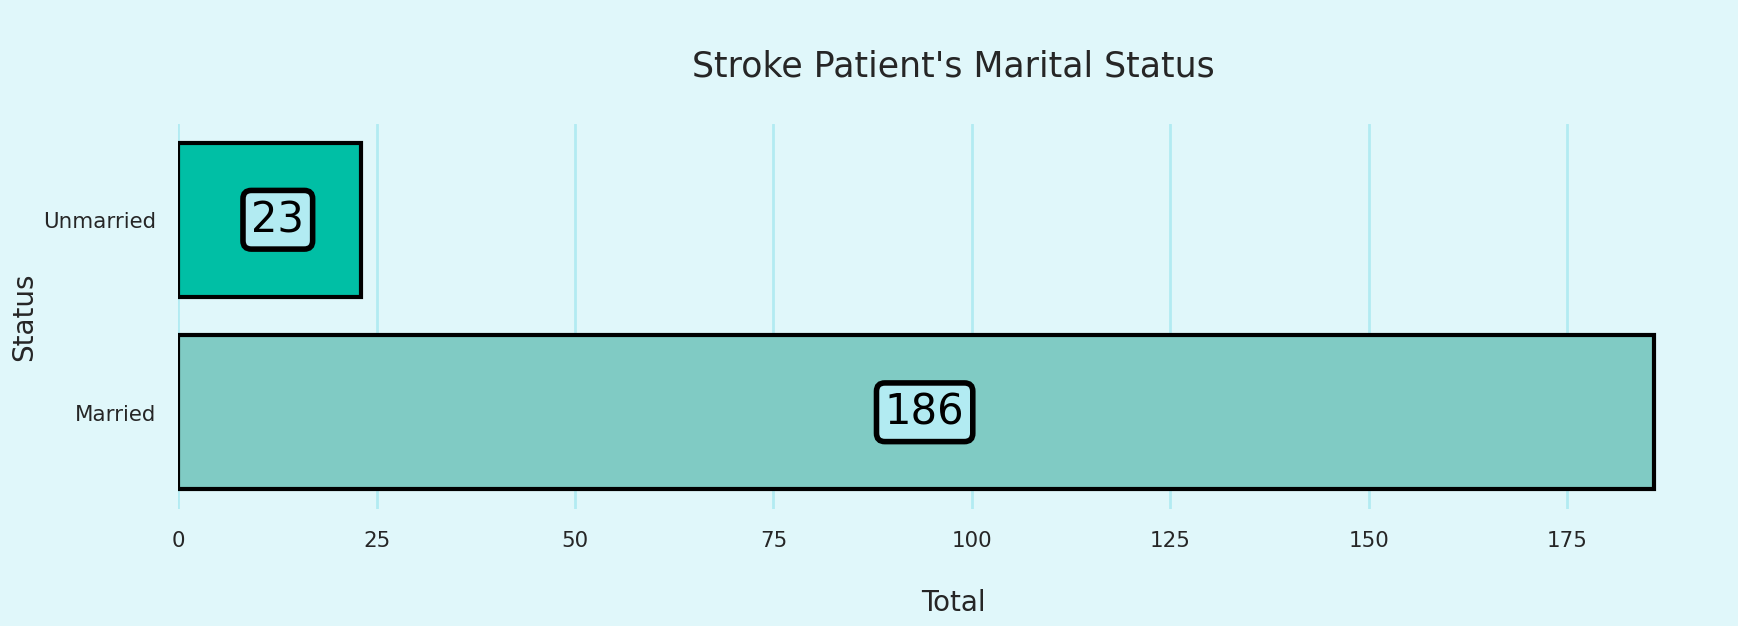

In [112]:
print("Let's have a look on the stroke patient's marital status :")
plt.subplots(figsize=(20, 5))

# Filter for stroke patients and get value counts for 'Marital Status'
marital_counts = data[data["Stroke"] == "Yes"]["Marital Status"].value_counts(ascending=True)
p=sns.barplot(y=marital_counts.index, x=marital_counts.values, palette=palette[0:2], saturation=1, edgecolor = "black", linewidth = 3)
# p.axes.set_yscale("symlog")
p.axes.set_title("\nStroke Patient's Marital Status\n",fontsize=25)
p.axes.set_ylabel("Status",fontsize=20)
p.axes.set_xlabel("\nTotal",fontsize=20)
p.axes.set_yticklabels(p.get_yticklabels(),rotation = 0)
for container in p.containers:
    p.bar_label(container,label_type="center",padding=6,size=30,color="black",rotation=0,
    bbox={"boxstyle": "round", "pad": 0.2, "facecolor": palette_cmap[0], "edgecolor": "black", "linewidth" : 4, "alpha": 1})

sns.despine(left=True, bottom=True)
plt.show()

**Insights:**

* Most of the stroke patients are **Married** with a ratio of **89.00%** followed by **Unmarried** with a ratio of **11.00%**

<a id="11"></a>
# <p style="padding:10px;background-color:#E0F7FA;margin:0;color:#00796B;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">Stroke Patient's BMI</p>

Let's have a look on the distribution of stroke patient's BMI :


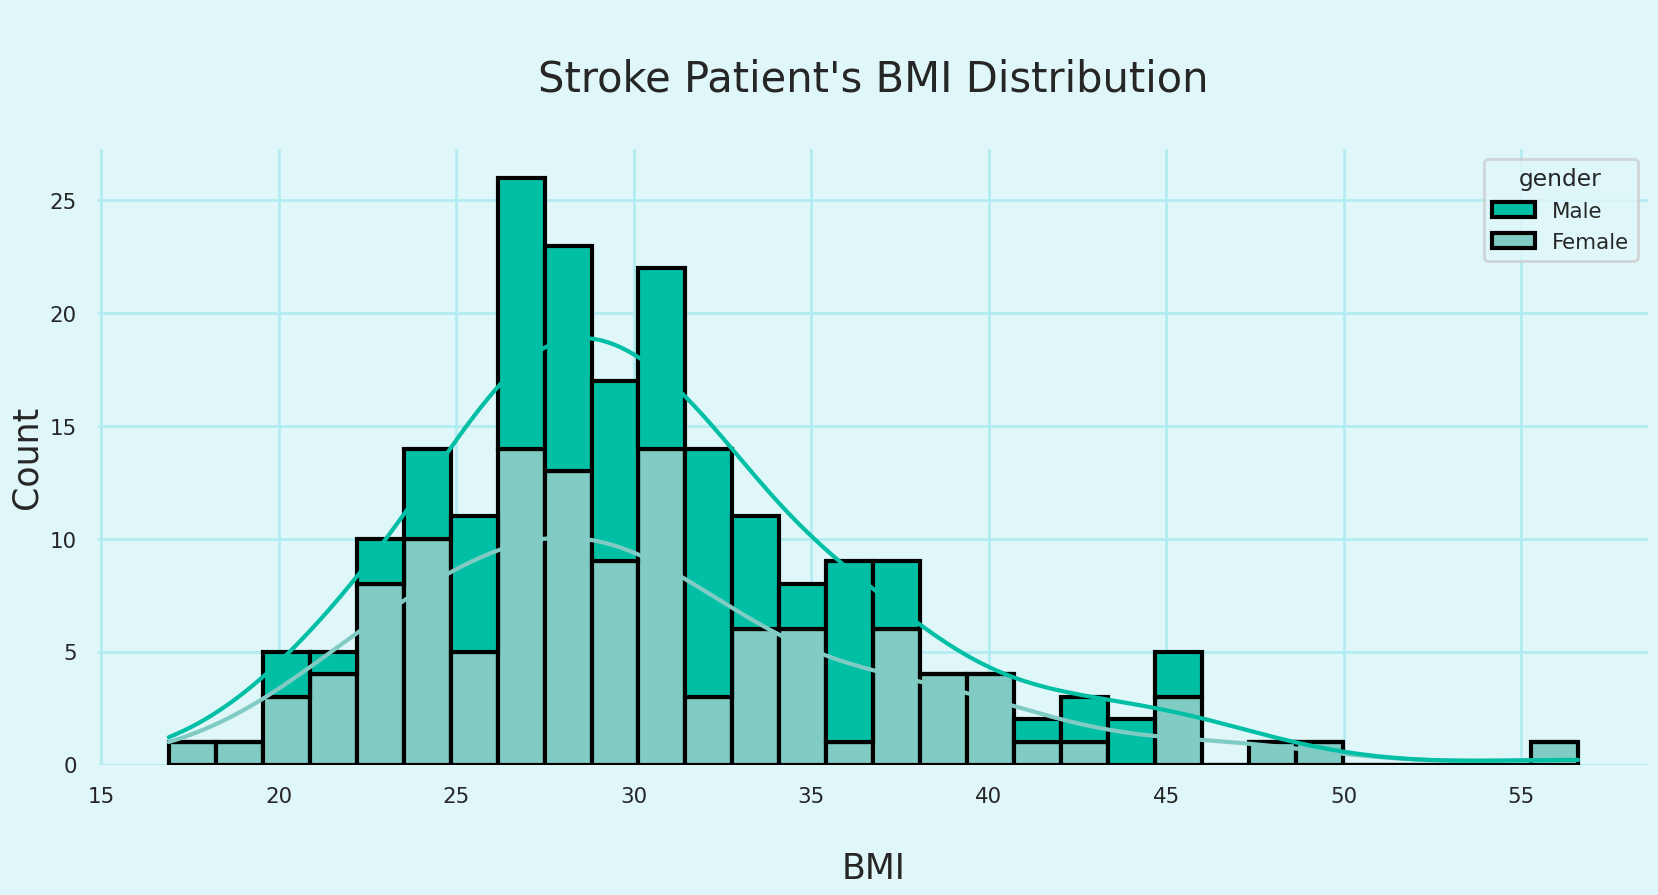

In [73]:
print(f"Let's have a look on the distribution of stroke patient's BMI :")
plt.subplots(figsize=(20, 8))
p = sns.histplot(data=data[data["stroke"] == 1],x="bmi",hue="gender",multiple="stack",palette=palette[0:2],kde=True,bins=30,alpha=1,fill=True,edgecolor="black",linewidth=3)
p.axes.lines[0].set_color(palette[1])
p.axes.lines[1].set_color(palette[0])
p.axes.set_title("\nStroke Patient's BMI Distribution\n",fontsize=30)
p.set_ylabel("Count",fontsize=25)
p.set_xlabel("\nBMI",fontsize=25)
p.set_yscale("linear")
sns.despine(left=True, bottom=True)

plt.show()

**Insights:**

* We can see the stroke patient's BMI distribution is right skewed. Most of the patient's BMI  fall in between **25** to **35**.
* Also there are some high BMI values too.

Let's have a look on the distribution of genderwise stroke patient's BMI :


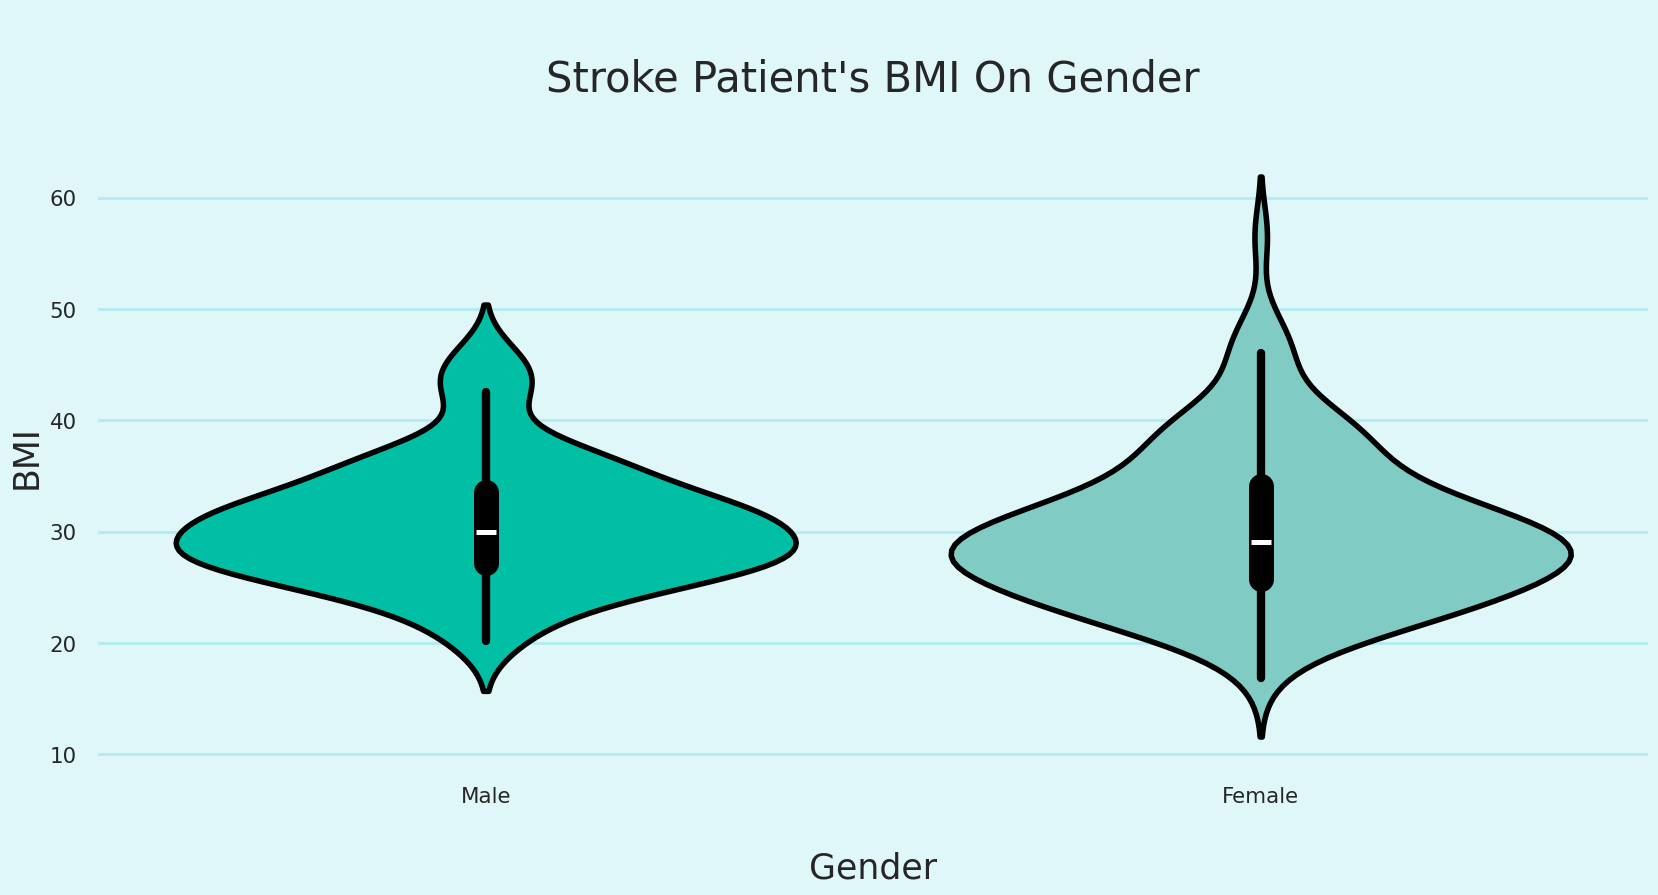

In [74]:
print("Let's have a look on the distribution of genderwise stroke patient's BMI :")
plt.subplots(figsize=(20, 8))

# Ensure order is based on filtered data
gender_order_bmi = data[data["stroke"] == 1]["gender"].value_counts(ascending=True).index
p=sns.violinplot(data=data[data["stroke"] == 1],x="gender",y="bmi",order=gender_order_bmi,palette=palette[0:2],saturation=1,linewidth=4,edgecolor="black")
p.axes.set_title("\nStroke Patient's BMI On Gender\n",fontsize=30)
p.axes.set_xlabel("\nGender",fontsize=25)
p.axes.set_ylabel("BMI",fontsize=25)

sns.despine(left=True, bottom=True)
plt.show()

**Insights:**

* Most of the **Male** patient's BMI fall in between **25** to **35**
* Most of the **Female** patient's BMI fall in between **23** to **31**

<a id="12"></a>
# <p style="padding:10px;background-color:#E0F7FA;margin:0;color:#00796B;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">Stroke Patient's Heart Disease</p>

Let's have a look on the distribution of stroke patient's heart disease status :


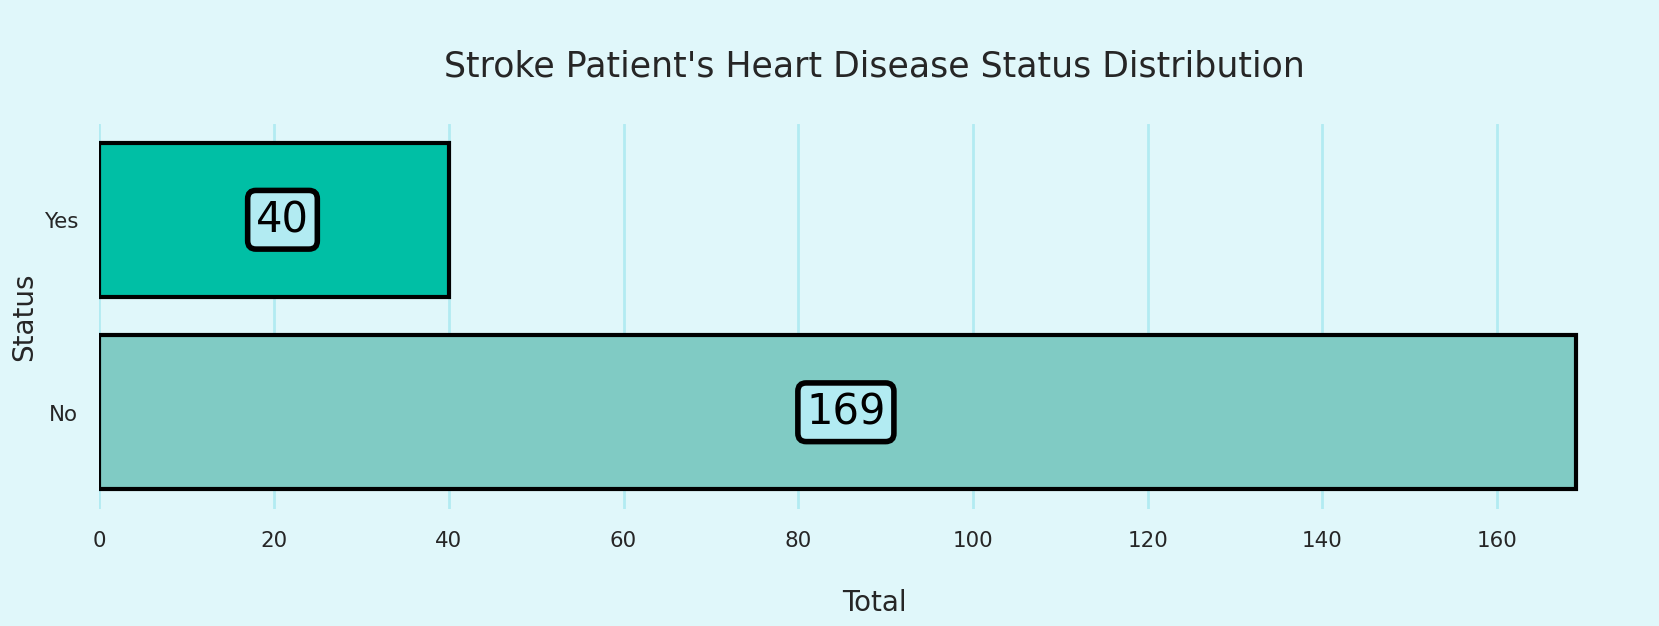

In [106]:
print(f"Let's have a look on the distribution of stroke patient's heart disease status :")
plt.subplots(figsize=(20, 5))

# Filter for stroke patients and get value counts for 'Heart Disease'
heart_disease_counts = data[data["Stroke"] == "Yes"]["Heart Disease"].value_counts(ascending=True)
p=sns.barplot(y=heart_disease_counts.index, x=heart_disease_counts.values, palette=palette[0:2], saturation=1, edgecolor = "black", linewidth = 3)
p.axes.set_title("\nStroke Patient's Heart Disease Status Distribution\n",fontsize=25)
p.axes.set_ylabel("Status",fontsize=20)
p.axes.set_xlabel("\nTotal",fontsize=20)
p.axes.set_yticklabels(p.get_yticklabels(),rotation = 0)
for container in p.containers:
    p.bar_label(container,label_type="center",padding=6,size=30,color="black",rotation=0,
    bbox={"boxstyle": "round", "pad": 0.2, "facecolor": palette_cmap[0], "edgecolor": "black", "linewidth" : 4, "alpha": 1})

sns.despine(left=True, bottom=True)
plt.show()

Let's have a look on the stroke patient's heart disease :


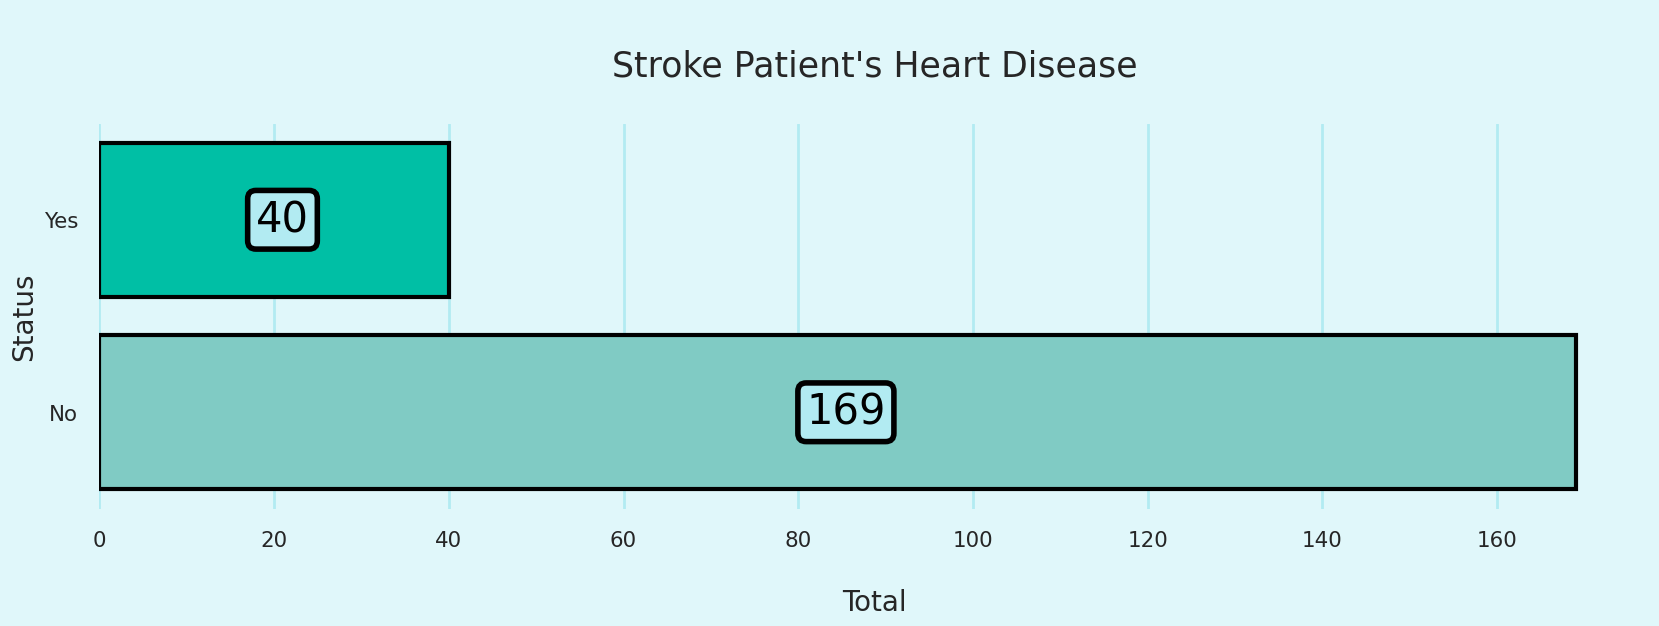

In [113]:
print("Let's have a look on the stroke patient's heart disease :")
plt.subplots(figsize=(20, 5))

# Filter for stroke patients and get value counts for 'Heart Disease'
heart_disease_counts = data[data["Stroke"] == "Yes"]["Heart Disease"].value_counts(ascending=True)
p=sns.barplot(y=heart_disease_counts.index, x=heart_disease_counts.values, palette=palette[0:2], saturation=1, edgecolor = "black", linewidth = 3)
# p.axes.set_yscale("symlog")
p.axes.set_title("\nStroke Patient's Heart Disease\n",fontsize=25)
p.axes.set_ylabel("Status",fontsize=20)
p.axes.set_xlabel("\nTotal",fontsize=20)
p.axes.set_yticklabels(p.get_yticklabels(),rotation = 0)
for container in p.containers:
    p.bar_label(container,label_type="center",padding=6,size=30,color="black",rotation=0,
    bbox={"boxstyle": "round", "pad": 0.2, "facecolor": palette_cmap[0], "edgecolor": "black", "linewidth" : 4, "alpha": 1})

sns.despine(left=True, bottom=True)
plt.show()

**Insights:**

* Most of the stroke patients do not have heart disease. Only **19.14%** patients have heart disease

<a id="13"></a>
# <p style="padding:10px;background-color:#E0F7FA;margin:0;color:#00796B;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">Stroke Patient's Hypertension Status</p>

Let's have a look on the distribution of stroke patient's hypertension status :


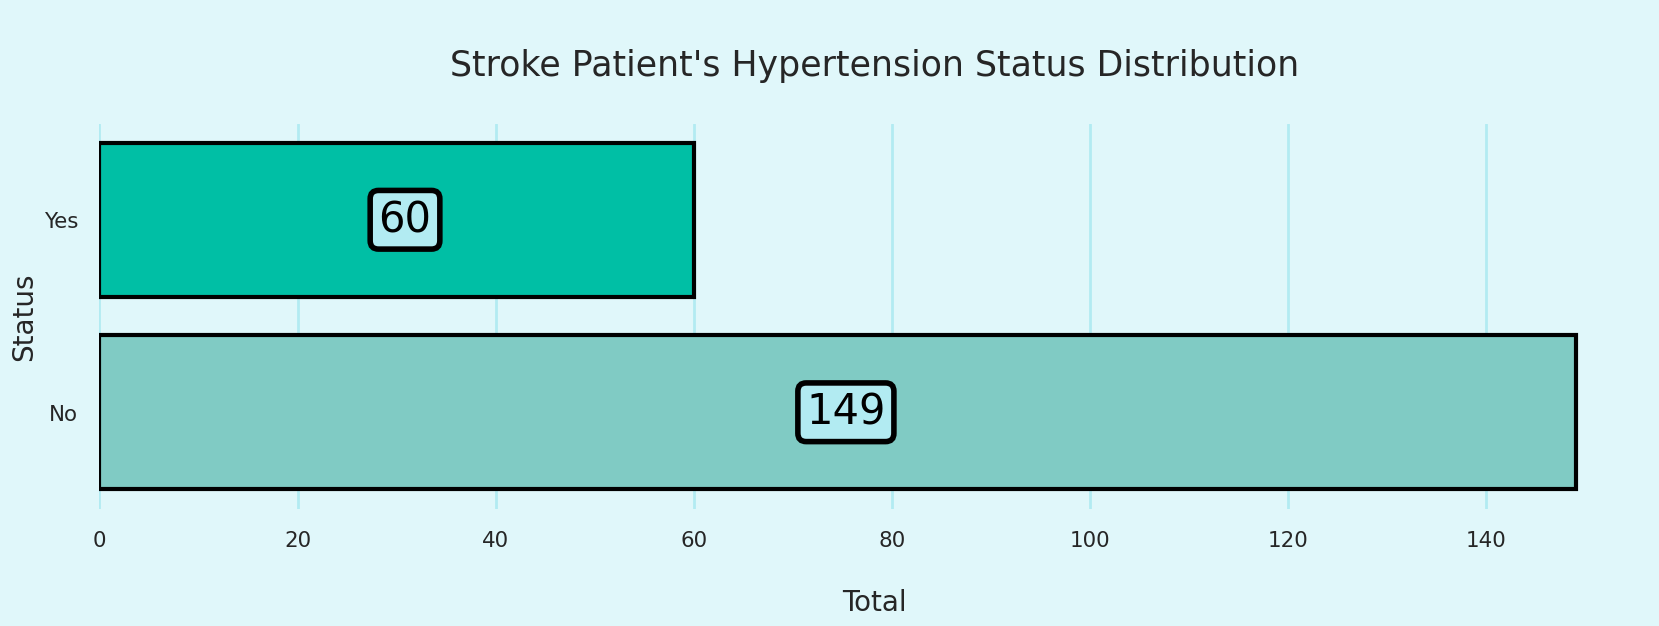

In [107]:
print(f"Let's have a look on the distribution of stroke patient's hypertension status :")
plt.subplots(figsize=(20, 5))

# Filter for stroke patients and get value counts for 'Hypertension'
hypertension_counts = data[data["Stroke"] == "Yes"]["Hypertension"].value_counts(ascending=True)
p=sns.barplot(y=hypertension_counts.index, x=hypertension_counts.values, palette=palette[0:2], saturation=1, edgecolor = "black", linewidth = 3)
p.axes.set_title("\nStroke Patient's Hypertension Status Distribution\n",fontsize=25)
p.axes.set_ylabel("Status",fontsize=20)
p.axes.set_xlabel("\nTotal",fontsize=20)
p.axes.set_yticklabels(p.get_yticklabels(),rotation = 0)
for container in p.containers:
    p.bar_label(container,label_type="center",padding=6,size=30,color="black",rotation=0,
    bbox={"boxstyle": "round", "pad": 0.2, "facecolor": palette_cmap[0], "edgecolor": "black", "linewidth" : 4, "alpha": 1})

sns.despine(left=True, bottom=True)
plt.show()

Let's have a look on the stroke patient's hypertension status :


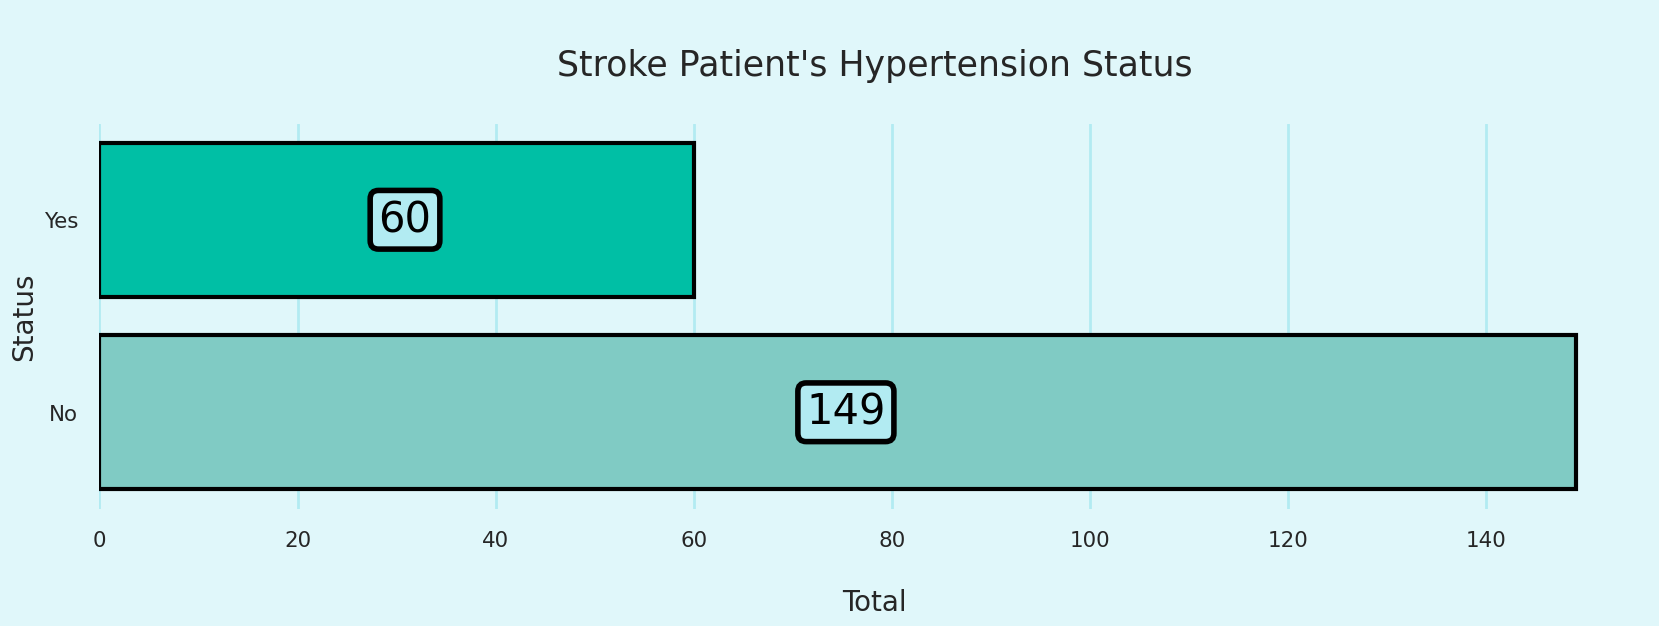

In [114]:
print("Let's have a look on the stroke patient's hypertension status :")
plt.subplots(figsize=(20, 5))

# Filter for stroke patients and get value counts for 'Hypertension'
hypertension_counts = data[data["Stroke"] == "Yes"]["Hypertension"].value_counts(ascending=True)
p=sns.barplot(y=hypertension_counts.index, x=hypertension_counts.values, palette=palette[0:2], saturation=1, edgecolor = "black", linewidth = 3)
# p.axes.set_yscale("symlog")
p.axes.set_title("\nStroke Patient's Hypertension Status\n",fontsize=25)
p.axes.set_ylabel("Status",fontsize=20)
p.axes.set_xlabel("\nTotal",fontsize=20)
p.axes.set_yticklabels(p.get_yticklabels(),rotation = 0)
for container in p.containers:
    p.bar_label(container,label_type="center",padding=6,size=30,color="black",rotation=0,
    bbox={"boxstyle": "round", "pad": 0.2, "facecolor": palette_cmap[0], "edgecolor": "black", "linewidth" : 4, "alpha": 1})

sns.despine(left=True, bottom=True)
plt.show()

**Insights:**

* Most of the stroke patients do not have hypertension. Only **28.71%** patients have hypertension

<a id="14"></a>
# <p style="padding:10px;background-color:#E0F7FA;margin:0;color:#00796B;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">Stroke Patient's Average Glucose Level</p>

Let's have a look on the distribution of stroke patient's average glucose level :


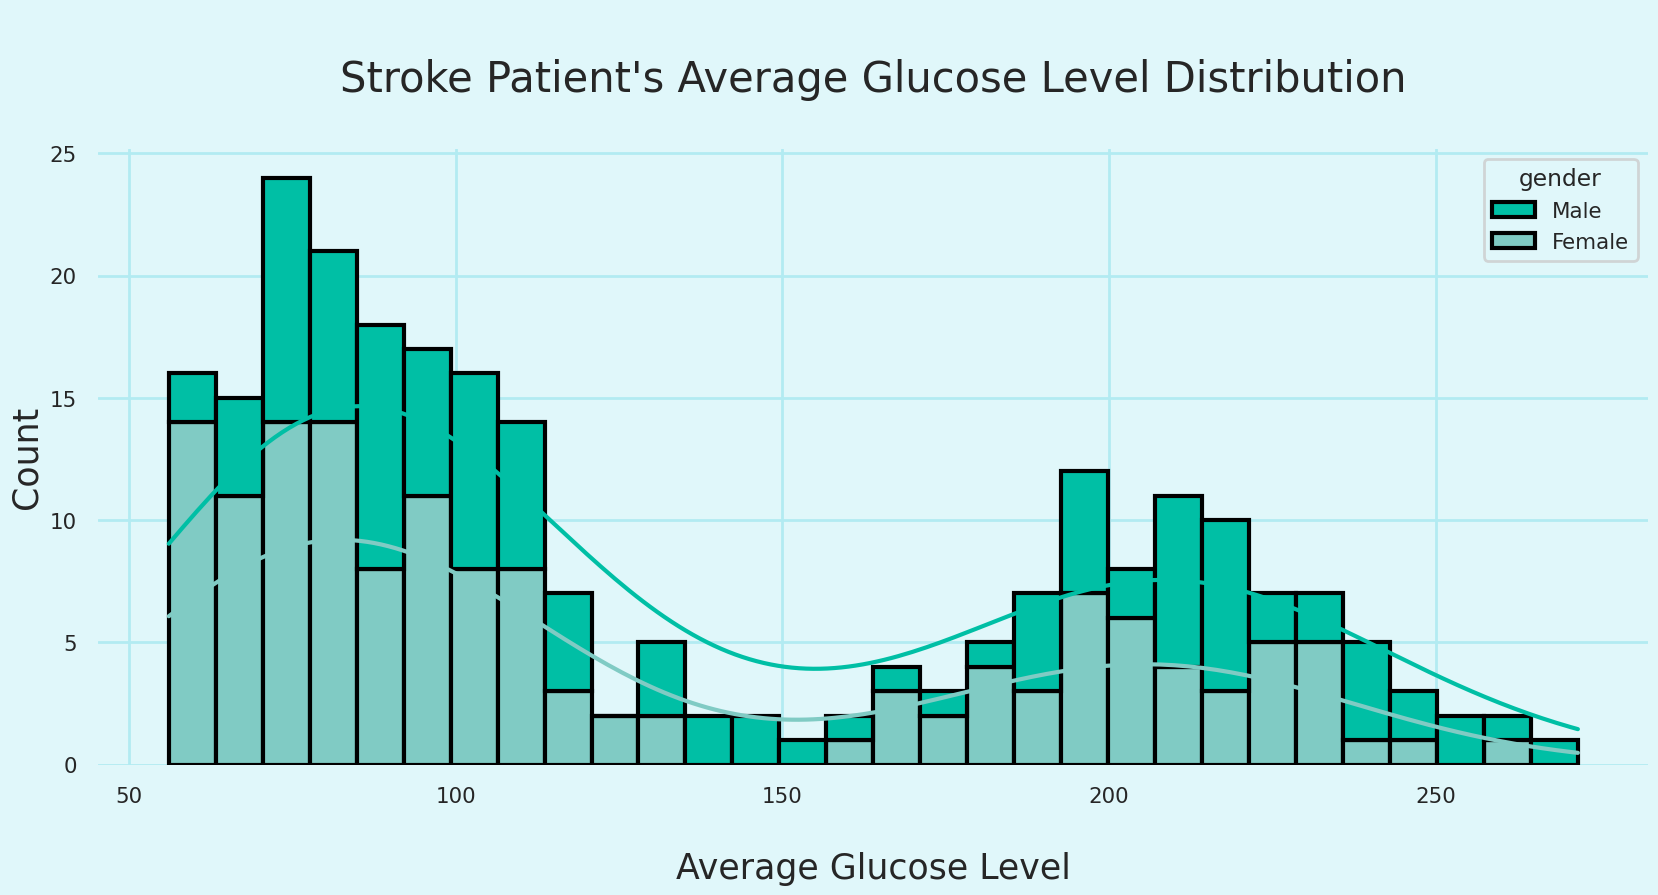

In [79]:
print(f"Let's have a look on the distribution of stroke patient's average glucose level :")
plt.subplots(figsize=(20, 8))
p = sns.histplot(data=data[data["stroke"]==1],x="avg_glucose_level",hue="gender",multiple="stack",palette=palette[0:2],kde=True,bins=30,alpha=1,fill=True,edgecolor="black",linewidth=3)
p.axes.lines[0].set_color(palette[1])
p.axes.lines[1].set_color(palette[0])
p.axes.set_title("\nStroke Patient's Average Glucose Level Distribution\n",fontsize=30)
p.set_ylabel("Count",fontsize=25)
p.set_xlabel("\nAverage Glucose Level",fontsize=25)
p.set_yscale("linear")
sns.despine(left=True, bottom=True)

plt.show()

**Insights:**

* We can see most of the patient's average glucose levels fall in between **60** to **120**
* Also there are some high average glucose levels too

Let's have a look on the distribution of genderwise stroke patient's Average Glucose Level :


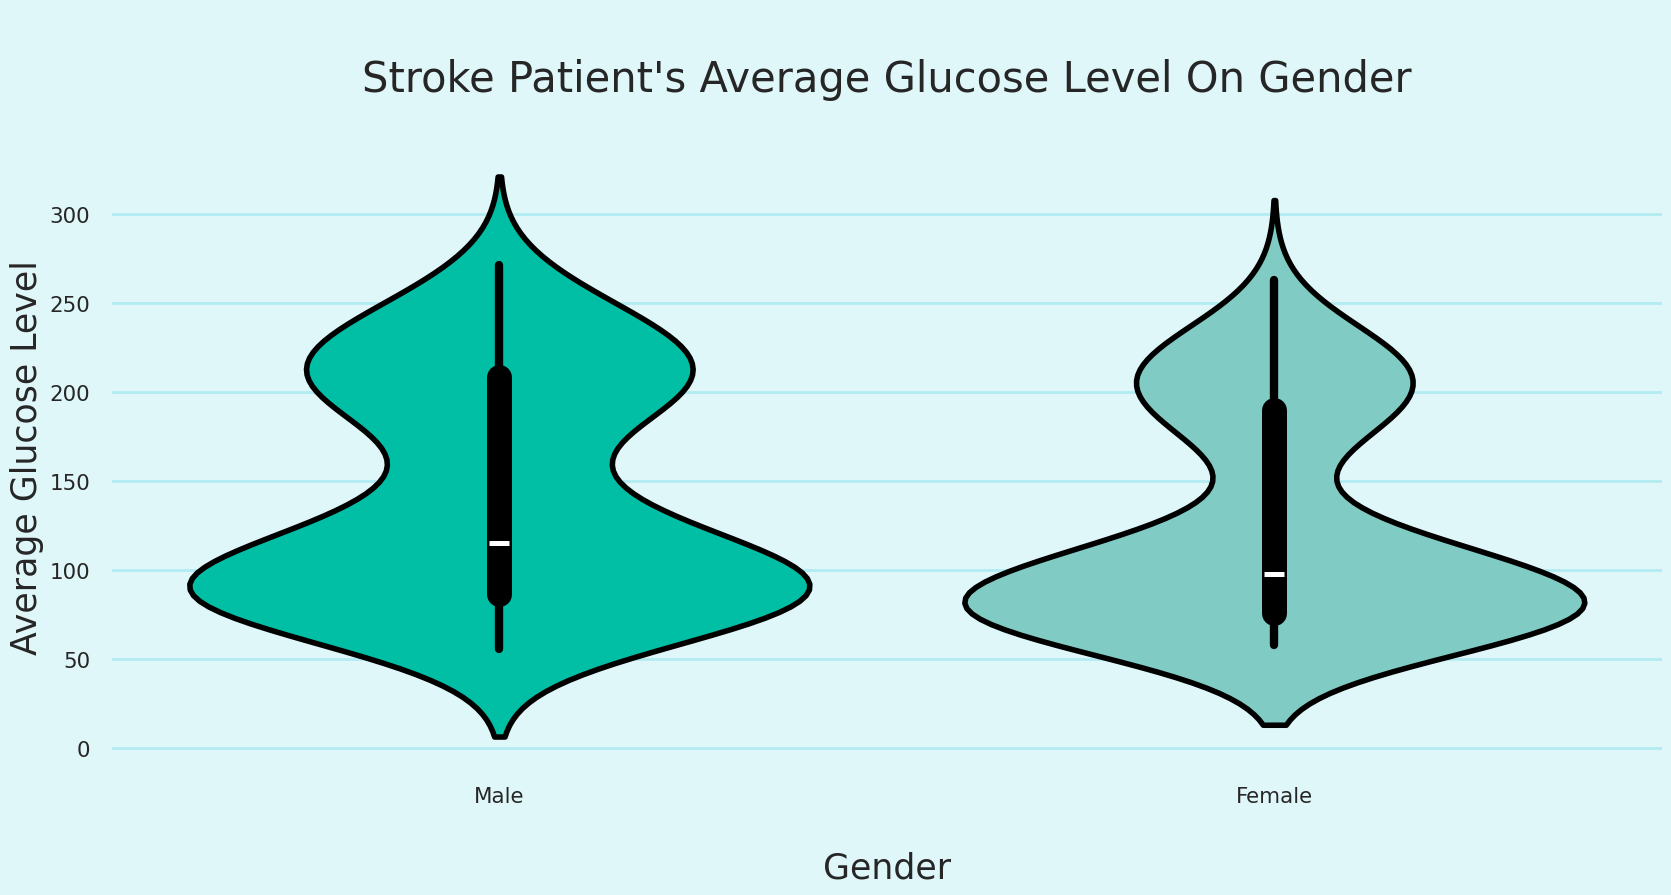

In [80]:
print("Let's have a look on the distribution of genderwise stroke patient's Average Glucose Level :")
plt.subplots(figsize=(20, 8))

# Ensure order is based on filtered data
gender_order_glucose = data[data["stroke"] == 1]["gender"].value_counts(ascending=True).index
p=sns.violinplot(data=data[data["stroke"]==1],x="gender",y="avg_glucose_level",order=gender_order_glucose,palette=palette[0:2],saturation=1,linewidth=4,edgecolor="black")
p.axes.set_title("\nStroke Patient's Average Glucose Level On Gender\n",fontsize=30)
p.axes.set_xlabel("\nGender",fontsize=25)
p.axes.set_ylabel("Average Glucose Level",fontsize=25)

sns.despine(left=True, bottom=True)
plt.show()

**Insights:**

* Most of the **Male** patient's average glucose levels fall in between **70** to **120**
* Most of the **Female** patient's average glucose levels fall in between **55** to **115**

<a id="15"></a>
# <p style="padding:10px;background-color:#E0F7FA;margin:0;color:#00796B;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">Stroke Patient's Occupation</p>

Let's have a look on the distribution of stroke patient's occupation type :


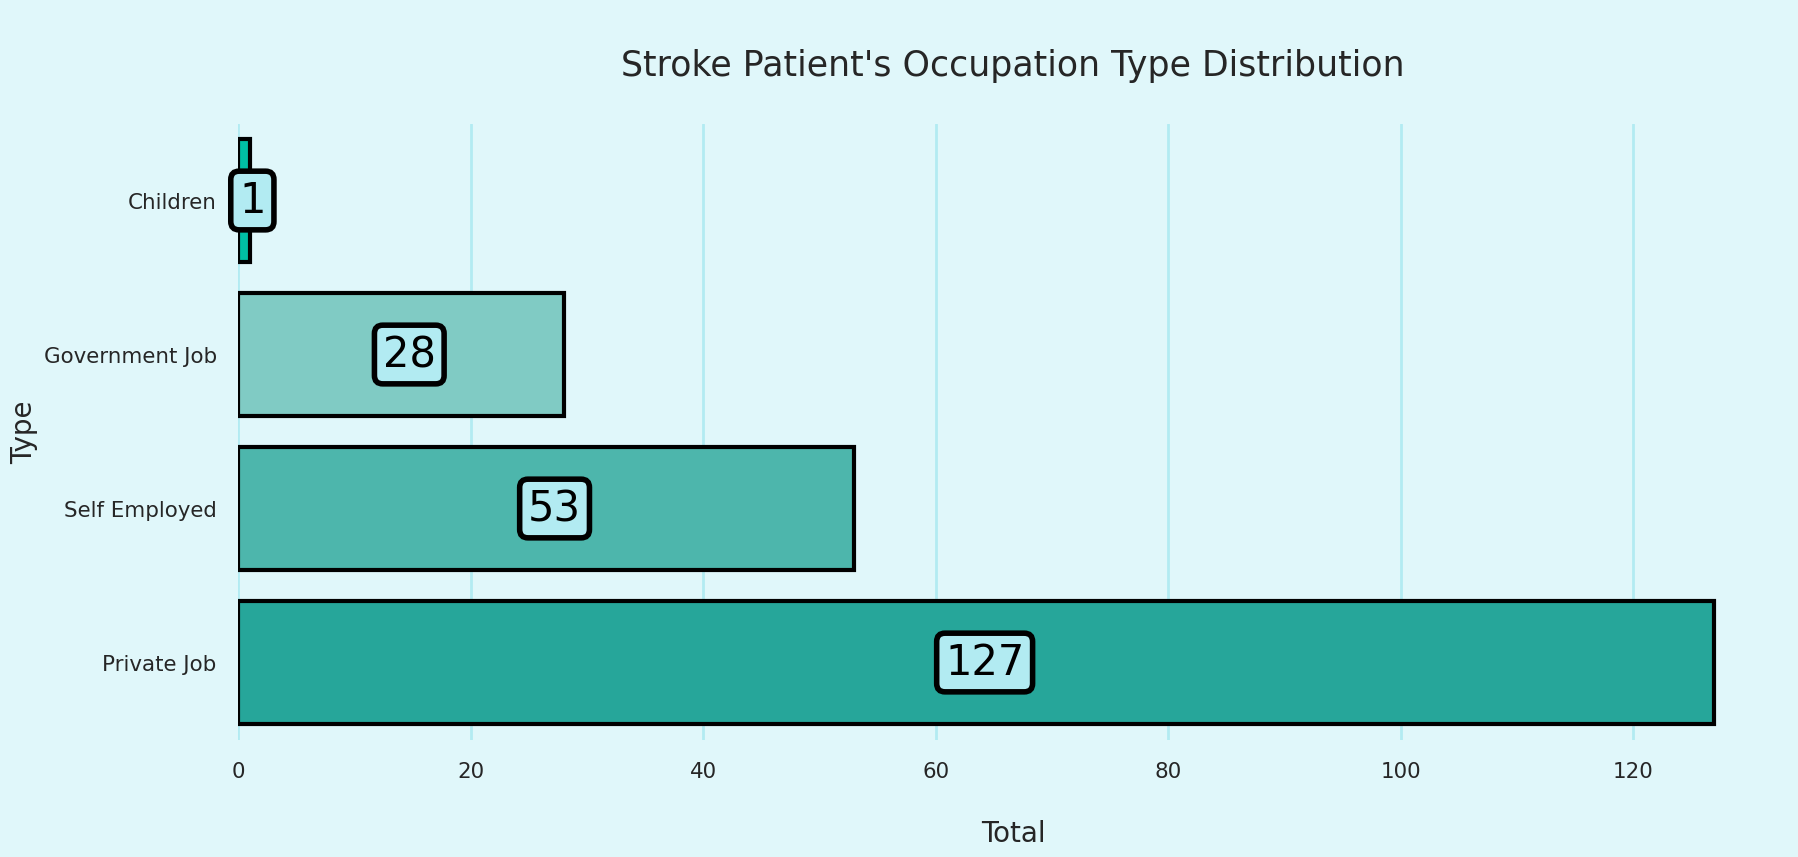

In [108]:
print(f"Let's have a look on the distribution of stroke patient's occupation type :")
plt.subplots(figsize=(20, 8))

# Filter for stroke patients and get value counts for 'Occupation Type'
occupation_counts = data[data["Stroke"] == "Yes"]["Occupation Type"].value_counts(ascending=True)
p=sns.barplot(y=occupation_counts.index, x=occupation_counts.values, palette=palette[0:5], saturation=1, edgecolor = "black", linewidth = 3)
p.axes.set_title("\nStroke Patient's Occupation Type Distribution\n",fontsize=25)
p.axes.set_ylabel("Type",fontsize=20)
p.axes.set_xlabel("\nTotal",fontsize=20)
p.axes.set_yticklabels(p.get_yticklabels(),rotation = 0)
for container in p.containers:
    p.bar_label(container,label_type="center",padding=6,size=30,color="black",rotation=0,
    bbox={"boxstyle": "round", "pad": 0.2, "facecolor": palette_cmap[0], "edgecolor": "black", "linewidth" : 4, "alpha": 1})

sns.despine(left=True, bottom=True)
plt.show()

Let's have a look on the stroke patient's occupation type :


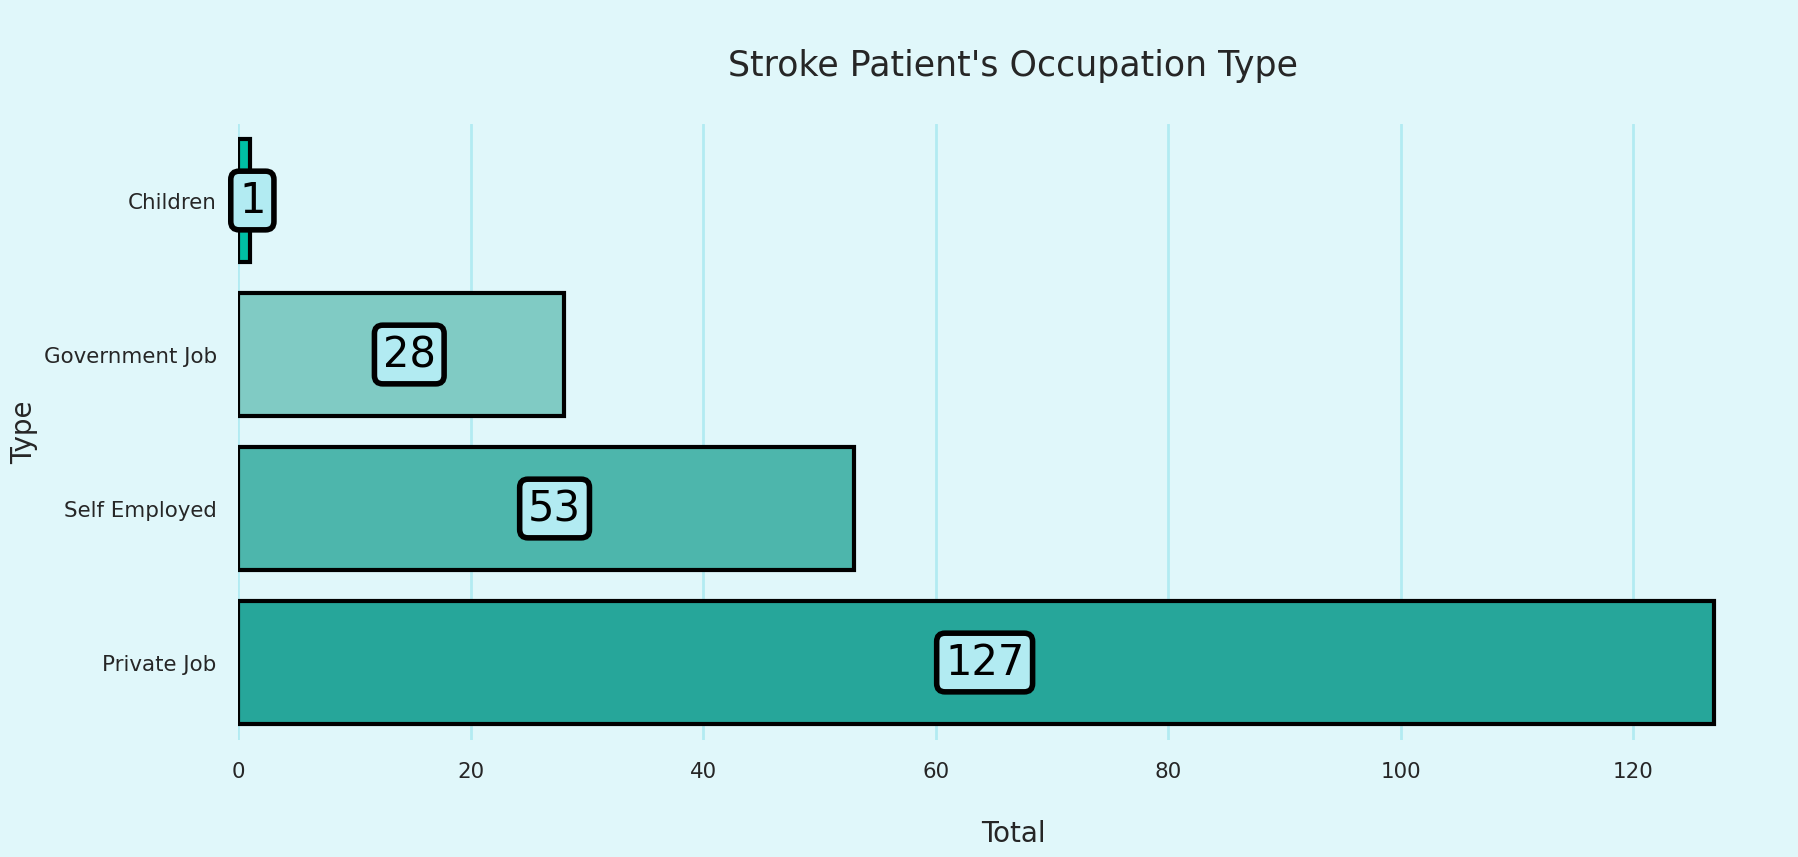

In [115]:
print("Let's have a look on the stroke patient's occupation type :")
plt.subplots(figsize=(20, 8))

# Filter for stroke patients and get value counts for 'Occupation Type'
occupation_counts = data[data["Stroke"] == "Yes"]["Occupation Type"].value_counts(ascending=True)
p=sns.barplot(y=occupation_counts.index, x=occupation_counts.values, palette=palette[0:5], saturation=1, edgecolor = "black", linewidth = 3)
# p.axes.set_yscale("symlog")
p.axes.set_title("\nStroke Patient's Occupation Type\n",fontsize=25)
p.axes.set_ylabel("Type",fontsize=20)
p.axes.set_xlabel("\nTotal",fontsize=20)
p.axes.set_yticklabels(p.get_yticklabels(),rotation = 0)
for container in p.containers:
    p.bar_label(container,label_type="center",padding=6,size=30,color="black",rotation=0,
    bbox={"boxstyle": "round", "pad": 0.2, "facecolor": palette_cmap[0], "edgecolor": "black", "linewidth" : 4, "alpha": 1})

sns.despine(left=True, bottom=True)
plt.show()

**Insights:**

* Most of the stroke patients have experience of **Private Job** with a ratio of **61.06%**
* Some of the stroke patients have experience of **Self Employment** with a ratio of **25.48%**
* Some of the stroke patients have experience of **Government Job** with a ratio of **13.46%**
* Only 1 patient is children that's why it was not included in the donut chart

<a id="16"></a>
# <p style="padding:10px;background-color:#E0F7FA;margin:0;color:#00796B;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">Stroke Patient's Residence</p>

Let's have a look on the distribution of stroke patient's residence type :


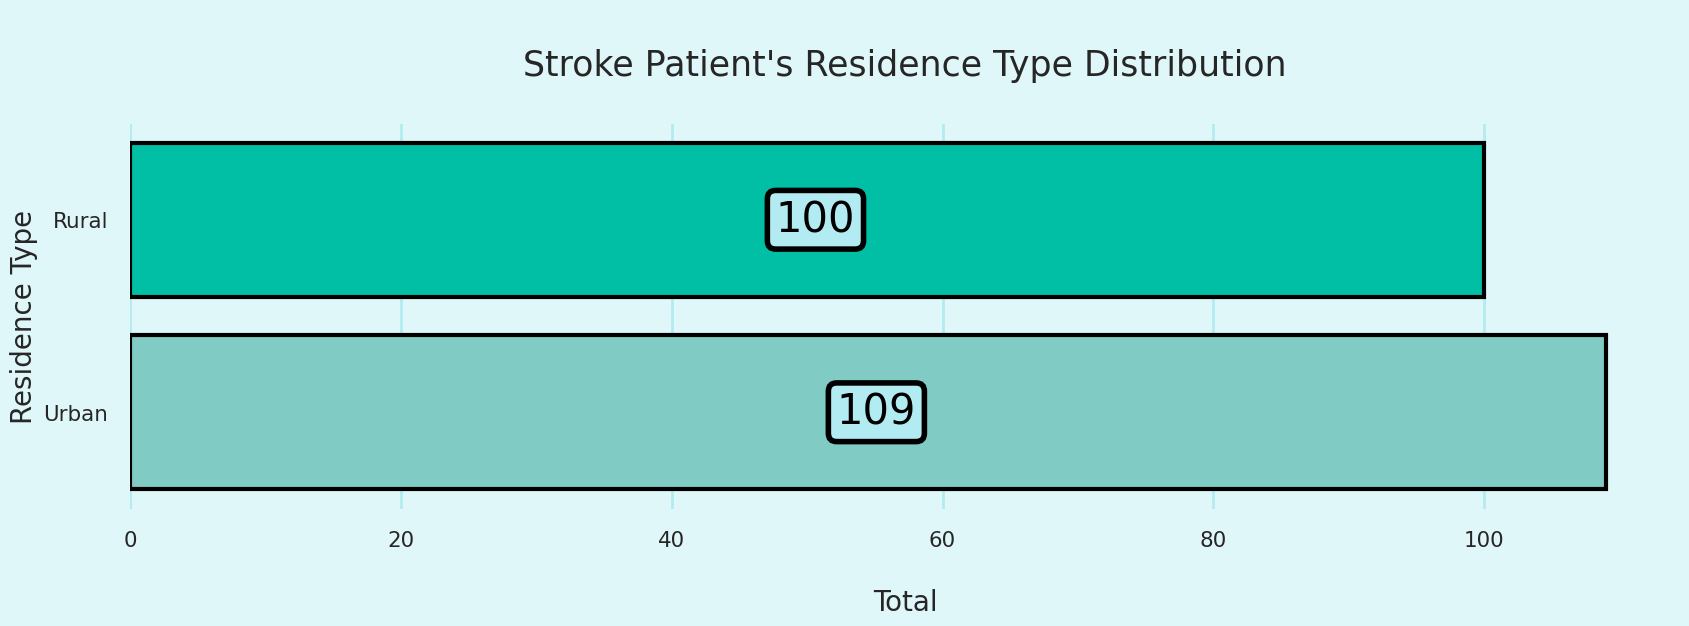

In [109]:
print(f"Let's have a look on the distribution of stroke patient's residence type :")
plt.subplots(figsize=(20, 5))

# Filter for stroke patients and get value counts for 'Residence Type'
residence_counts = data[data["Stroke"] == "Yes"]["Residence Type"].value_counts(ascending=True)
p=sns.barplot(y=residence_counts.index, x=residence_counts.values, palette=palette[0:2], saturation=1, edgecolor = "black", linewidth = 3)
p.axes.set_title("\nStroke Patient's Residence Type Distribution\n",fontsize=25)
p.axes.set_ylabel("Residence Type",fontsize=20)
p.axes.set_xlabel("\nTotal",fontsize=20)
p.axes.set_yticklabels(p.get_yticklabels(),rotation = 0)
for container in p.containers:
    p.bar_label(container,label_type="center",padding=6,size=30,color="black",rotation=0,
    bbox={"boxstyle": "round", "pad": 0.2, "facecolor": palette_cmap[0], "edgecolor": "black", "linewidth" : 4, "alpha": 1})

sns.despine(left=True, bottom=True)
plt.show()

Let's have a look on the stroke patient's residence type :


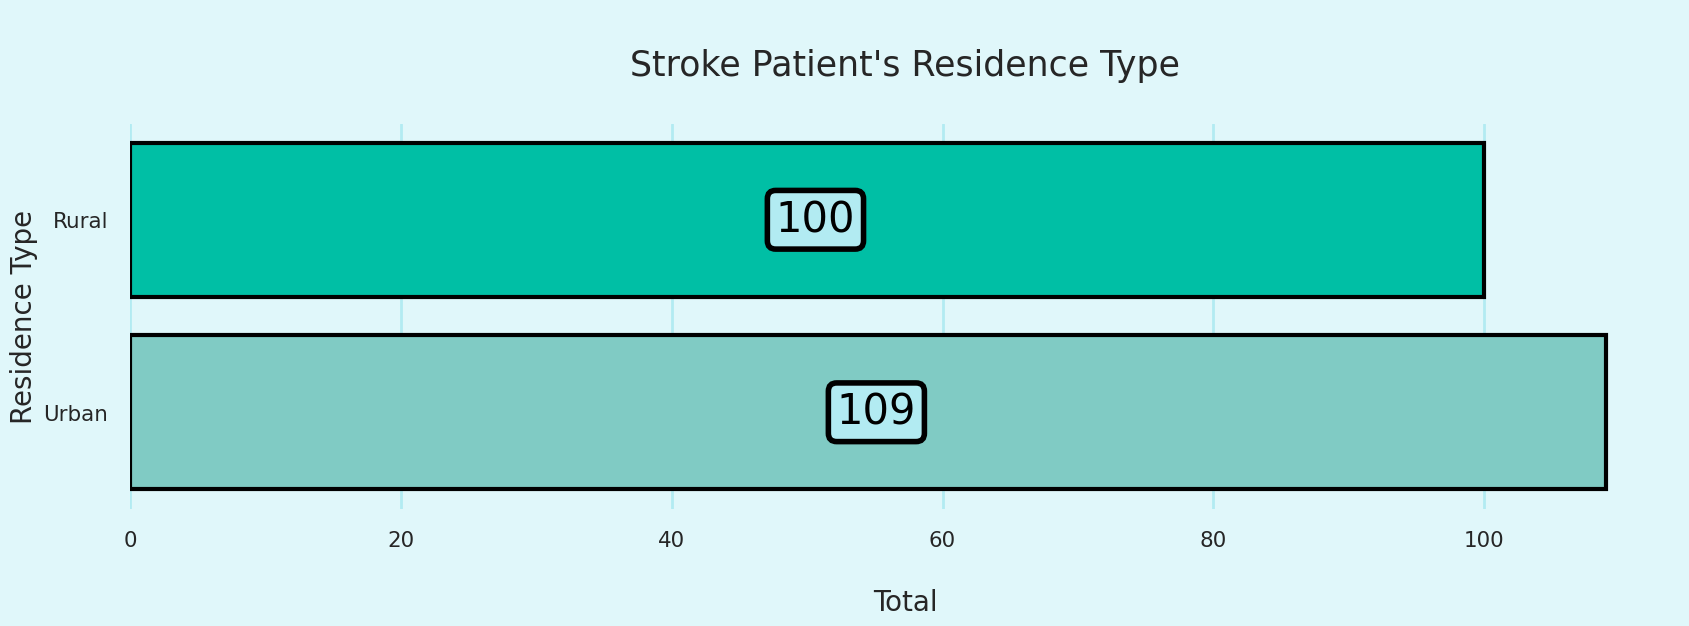

In [116]:
print("Let's have a look on the stroke patient's residence type :")
plt.subplots(figsize=(20, 5))

# Filter for stroke patients and get value counts for 'Residence Type'
residence_counts = data[data["Stroke"] == "Yes"]["Residence Type"].value_counts(ascending=True)
p=sns.barplot(y=residence_counts.index, x=residence_counts.values, palette=palette[0:2], saturation=1, edgecolor = "black", linewidth = 3)
# p.axes.set_yscale("symlog")
p.axes.set_title("\nStroke Patient's Residence Type\n",fontsize=25)
p.axes.set_ylabel("Residence Type",fontsize=20)
p.axes.set_xlabel("\nTotal",fontsize=20)
p.axes.set_yticklabels(p.get_yticklabels(),rotation = 0)
for container in p.containers:
    p.bar_label(container,label_type="center",padding=6,size=30,color="black",rotation=0,
    bbox={"boxstyle": "round", "pad": 0.2, "facecolor": palette_cmap[0], "edgecolor": "black", "linewidth" : 4, "alpha": 1})

sns.despine(left=True, bottom=True)
plt.show()

**Insights:**

* **52.15%** patients live in **Urban** area and **47.85%** patients live in **Rural** area

<a id="17"></a>
# <p style="padding:10px;background-color:#E0F7FA;margin:0;color:#00796B;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">Correlation Map</p>

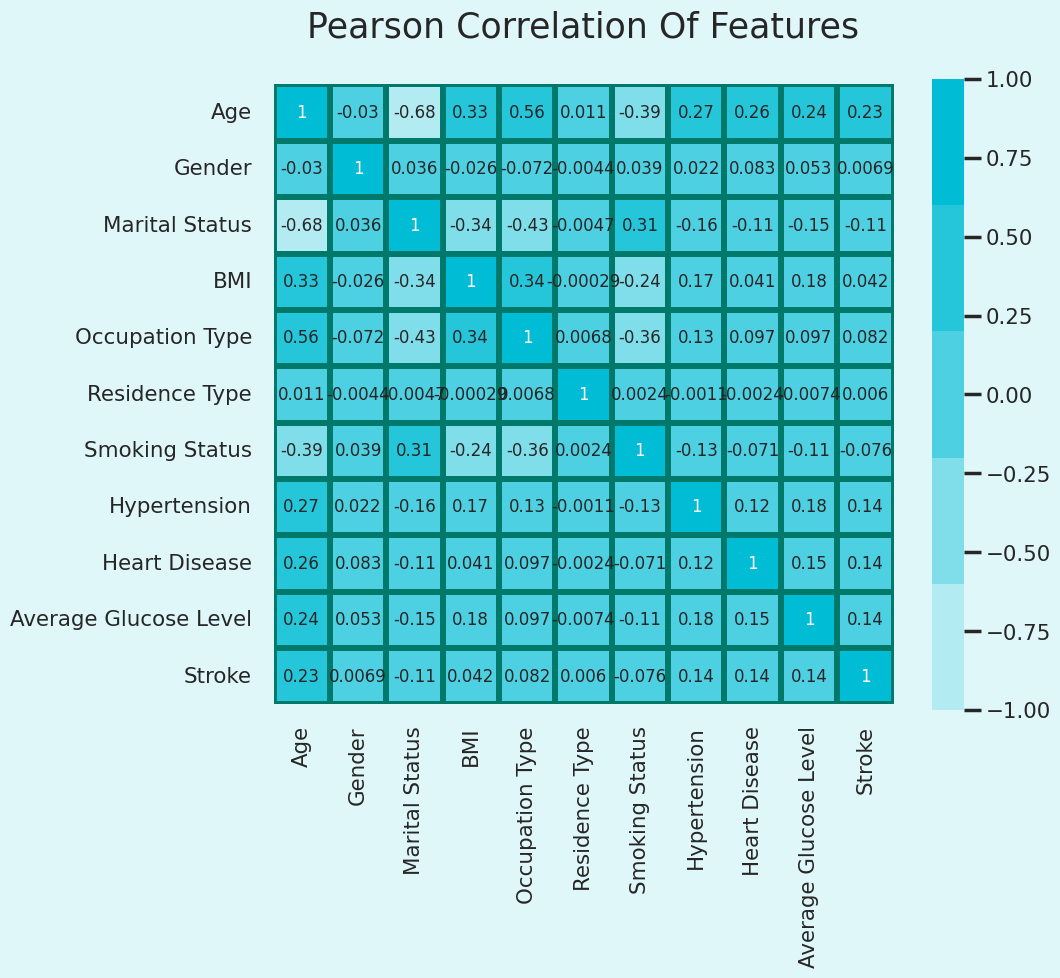

In [117]:
data_corr = data.copy() # Create a copy of the DataFrame for correlation analysis

catcol = [col for col in data_corr.columns if data_corr[col].dtype == "object"]
le = LabelEncoder()
for col in catcol:
        data_corr[col] = le.fit_transform(data_corr[col])


plt.subplots(figsize =(10, 10))

sns.heatmap(data_corr.corr(), cmap = palette_cmap, square=True, cbar_kws=dict(shrink =.82),
            annot=True, vmin=-1, vmax=1, linewidths=3,linecolor=palette[4],annot_kws=dict(fontsize =12))
plt.title("Pearson Correlation Of Features\n", fontsize=25)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

**Insights:**

* We can see there is not any high correlation between target feature and other features. Small positive correlation between target feature and **Age**, **Hypertension**, **Heart Disease**, **Average Glucose Level**.
* Small positive correlation between **Age** and **Stroke**, **Hypertension**, **Heart Disease**, **Average Glucose Level**, **BMI**.
* Small positive correlation between **Smoking Status** and **Marital Status**, **Occupation Type** and **BMI**.
* Medium positive correlation between **Age** and **Occupation Type**.
* Medium negative correlation between **Age** and **Marital Status**.

<a id="18"></a>
# <p style="padding:10px;background-color:#E0F7FA;margin:0;color:#00796B;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">Model Creation & Performance Evaluation</p>

After performing standardization, we have splitted the dataset with a ratio of 0.2 that means 80% data for training and 20% data for validation process.

In [40]:
x = data.drop(["Stroke"],axis =1)
y = data["Stroke"]

sc = StandardScaler()
x = sc.fit_transform(x)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(f"Shape of training data : {x_train.shape}, {y_train.shape}")
print(f"Shape of testing data : {x_test.shape}, {y_test.shape}")

Shape of training data : (3926, 10), (3926,)
Shape of testing data : (982, 10), (982,)


<center> <span style="font-family:newtimeroman"> <span style="padding:5px;display:fill;border-radius:20px 50px;background-color:#E0F7FA;font-size:200%;font-weight: 500;color:#00796B;overflow:hidden;">ㅤLogistic Regressionㅤ</span>

In [42]:
lr = LogisticRegression()
lr.fit(x_train, y_train)
lr_pred = lr.predict(x_test)
lr_conf = confusion_matrix(y_test, lr_pred)
lr_report = classification_report(y_test, lr_pred)
lr_acc = round(accuracy_score(y_test, lr_pred)*100, ndigits = 2)
print(f"Confusion Matrix : \n\n{lr_conf}")
print(f"\nClassification Report : \n\n{lr_report}")
print(f"\nThe Accuracy of Logistic Regression is {lr_acc} %")

Confusion Matrix : 

[[929   0]
 [ 53   0]]

Classification Report : 

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       929
           1       0.00      0.00      0.00        53

    accuracy                           0.95       982
   macro avg       0.47      0.50      0.49       982
weighted avg       0.89      0.95      0.92       982


The Accuracy of Logistic Regression is 94.6 %


<center> <span style="font-family:newtimeroman"> <span style="padding:5px;display:fill;border-radius:20px 50px;background-color:#E0F7FA;font-size:200%;font-weight: 500;color:#00796B;overflow:hidden;">ㅤGaussian Naive Bayesㅤ</span>

In [44]:
gnb = GaussianNB()
gnb.fit(x_train, y_train)
gnb_pred = gnb.predict(x_test)
gnb_conf = confusion_matrix(y_test, gnb_pred)
gnb_report = classification_report(y_test, gnb_pred)
gnb_acc = round(accuracy_score(y_test, gnb_pred)*100, ndigits = 2)
print(f"Confusion Matrix : \n\n{gnb_conf}")
print(f"\nClassification Report : \n\n{gnb_report}")
print(f"\nThe Accuracy of Gaussian Naive Bayes is {gnb_acc} %")

Confusion Matrix : 

[[822 107]
 [ 30  23]]

Classification Report : 

              precision    recall  f1-score   support

           0       0.96      0.88      0.92       929
           1       0.18      0.43      0.25        53

    accuracy                           0.86       982
   macro avg       0.57      0.66      0.59       982
weighted avg       0.92      0.86      0.89       982


The Accuracy of Gaussian Naive Bayes is 86.05 %


<center> <span style="font-family:newtimeroman"> <span style="padding:5px;display:fill;border-radius:20px 50px;background-color:#E0F7FA;font-size:200%;font-weight: 500;color:#00796B;overflow:hidden;">ㅤBernoulli Naive Bayesㅤ</span>

In [45]:
bnb = BernoulliNB()
bnb.fit(x_train, y_train)
bnb_pred = bnb.predict(x_test)
bnb_conf = confusion_matrix(y_test, bnb_pred)
bnb_report = classification_report(y_test, bnb_pred)
bnb_acc = round(accuracy_score(y_test, bnb_pred)*100, ndigits = 2)
print(f"Confusion Matrix : \n\n{bnb_conf}")
print(f"\nClassification Report : \n\n{bnb_report}")
print(f"\nThe Accuracy of Bernoulli Naive Bayes is {bnb_acc} %")

Confusion Matrix : 

[[917  12]
 [ 51   2]]

Classification Report : 

              precision    recall  f1-score   support

           0       0.95      0.99      0.97       929
           1       0.14      0.04      0.06        53

    accuracy                           0.94       982
   macro avg       0.55      0.51      0.51       982
weighted avg       0.90      0.94      0.92       982


The Accuracy of Bernoulli Naive Bayes is 93.58 %


<center> <span style="font-family:newtimeroman"> <span style="padding:5px;display:fill;border-radius:20px 50px;background-color:#E0F7FA;font-size:200%;font-weight: 500;color:#00796B;overflow:hidden;">ㅤSupport Vector Machineㅤ</span>

In [46]:
svm = SVC(C = 100, gamma = 0.002)
svm.fit(x_train, y_train)
svm_pred = svm.predict(x_test)
svm_conf = confusion_matrix(y_test, svm_pred)
svm_report = classification_report(y_test, svm_pred)
svm_acc = round(accuracy_score(y_test, svm_pred)*100, ndigits = 2)
print(f"Confusion Matrix : \n\n{svm_conf}")
print(f"\nClassification Report : \n\n{svm_report}")
print(f"\nThe Accuracy of Support Vector Machine is {svm_acc} %")

Confusion Matrix : 

[[929   0]
 [ 53   0]]

Classification Report : 

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       929
           1       0.00      0.00      0.00        53

    accuracy                           0.95       982
   macro avg       0.47      0.50      0.49       982
weighted avg       0.89      0.95      0.92       982


The Accuracy of Support Vector Machine is 94.6 %


<center> <span style="font-family:newtimeroman"> <span style="padding:5px;display:fill;border-radius:20px 50px;background-color:#E0F7FA;font-size:200%;font-weight: 500;color:#00796B;overflow:hidden;">ㅤRandom Forestㅤ</span>

In [47]:
rfg = RandomForestClassifier(n_estimators = 100, random_state = 42)
rfg.fit(x_train, y_train)
rfg_pred = rfg.predict(x_test)
rfg_conf = confusion_matrix(y_test, rfg_pred)
rfg_report = classification_report(y_test, rfg_pred)
rfg_acc = round(accuracy_score(y_test, rfg_pred)*100, ndigits = 2)
print(f"Confusion Matrix : \n\n{rfg_conf}")
print(f"\nClassification Report : \n\n{rfg_report}")
print(f"\nThe Accuracy of Random Forest Classifier is {rfg_acc} %")

Confusion Matrix : 

[[929   0]
 [ 53   0]]

Classification Report : 

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       929
           1       0.00      0.00      0.00        53

    accuracy                           0.95       982
   macro avg       0.47      0.50      0.49       982
weighted avg       0.89      0.95      0.92       982


The Accuracy of Random Forest Classifier is 94.6 %


<center> <span style="font-family:newtimeroman"> <span style="padding:5px;display:fill;border-radius:20px 50px;background-color:#E0F7FA;font-size:200%;font-weight: 500;color:#00796B;overflow:hidden;">ㅤK Nearest Neighborsㅤ</span>

In [48]:
knn = KNeighborsClassifier(n_neighbors=2)
knn.fit(x_train, y_train)
knn_pred = knn.predict(x_test)
knn_conf = confusion_matrix(y_test, knn_pred)
knn_report = classification_report(y_test, knn_pred)
knn_acc = round(accuracy_score(y_test, knn_pred)*100, ndigits = 2)
print(f"Confusion Matrix : \n\n{knn_conf}")
print(f"\nClassification Report : \n\n{knn_report}")
print(f"\nThe Accuracy of K Nearest Neighbors Classifier is {knn_acc} %")

Confusion Matrix : 

[[928   1]
 [ 53   0]]

Classification Report : 

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       929
           1       0.00      0.00      0.00        53

    accuracy                           0.95       982
   macro avg       0.47      0.50      0.49       982
weighted avg       0.89      0.95      0.92       982


The Accuracy of K Nearest Neighbors Classifier is 94.5 %


<center> <span style="font-family:newtimeroman"> <span style="padding:5px;display:fill;border-radius:20px 50px;background-color:#E0F7FA;font-size:200%;font-weight: 500;color:#00796B;overflow:hidden;">ㅤExtreme Gradient Boostingㅤ</span>

In [49]:
xgb = XGBClassifier(use_label_encoder = False)
xgb.fit(x_train, y_train)
xgb_pred = xgb.predict(x_test)
xgb_conf = confusion_matrix(y_test, xgb_pred)
xgb_report = classification_report(y_test, xgb_pred)
xgb_acc = round(accuracy_score(y_test, xgb_pred)*100, ndigits = 2)
print(f"Confusion Matrix : \n\n{xgb_conf}")
print(f"\nClassification Report : \n\n{xgb_report}")
print(f"\nThe Accuracy of Extreme Gradient Boosting Classifier is {xgb_acc} %")

Confusion Matrix : 

[[922   7]
 [ 51   2]]

Classification Report : 

              precision    recall  f1-score   support

           0       0.95      0.99      0.97       929
           1       0.22      0.04      0.06        53

    accuracy                           0.94       982
   macro avg       0.58      0.52      0.52       982
weighted avg       0.91      0.94      0.92       982


The Accuracy of Extreme Gradient Boosting Classifier is 94.09 %


<center> <span style="font-family:newtimeroman"> <span style="padding:5px;display:fill;border-radius:20px 50px;background-color:#E0F7FA;font-size:200%;font-weight: 500;color:#00796B;overflow:hidden;">ㅤNeural Network Architectureㅤ</span>

In [50]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam

regularization_parameter = 0.003

neural_model = Sequential([tf.keras.layers.Dense(units=32, input_dim=(x_train.shape[-1]), activation="relu", kernel_regularizer = regularizers.l1(regularization_parameter)),
                    tf.keras.layers.Dense(units=64, activation="relu", kernel_regularizer = regularizers.l1(regularization_parameter)),
                    tf.keras.layers.Dense(units=128, activation="relu", kernel_regularizer = regularizers.l1(regularization_parameter)),
                    tf.keras.layers.Dropout(0.3),
                    tf.keras.layers.Dense(units=16,activation="relu", kernel_regularizer = regularizers.l1(regularization_parameter)),
                    tf.keras.layers.Dense(units=1, activation="sigmoid")
                    ])

print(neural_model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │         2,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,865 (50.25 KB)

 Trainable params: 12,865 (50.25 KB)

 Non-trainable params: 0 (0.00 B)

None


In [51]:
class myCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if(logs.get("accuracy") == 1.0):
            print("\nAccuracy is 100% so canceling training!")
            self.model.stop_training = True

callbacks = myCallback()


neural_model.compile(optimizer = Adam(learning_rate = 0.001),
                     loss = "binary_crossentropy",
                     metrics = ["accuracy"])

history = neural_model.fit(x_train, y_train,
                           epochs = 150,
                           verbose = 1,
                           batch_size = 64,
                           validation_data = (x_test, y_test),
                           callbacks = [callbacks])

Epoch 1/150
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9465 - loss: 3.2243 - val_accuracy: 0.9460 - val_loss: 2.3219
Epoch 2/150
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9603 - loss: 1.6618 - val_accuracy: 0.9460 - val_loss: 1.1450
Epoch 3/150
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9603 - loss: 0.7941 - val_accuracy: 0.9460 - val_loss: 0.5981
Epoch 4/150
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9603 - loss: 0.4702 - val_accuracy: 0.9460 - val_loss: 0.4318
Epoch 5/150
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9603 - loss: 0.3611 - val_accuracy: 0.9460 - val_loss: 0.3642
Epoch 6/150
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9603 - loss: 0.3080 - val_accuracy: 0.9460 - val_loss: 0.3240
Epoch 7/150
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9603 - loss: 0.2788 - val_accuracy: 0.9460 - val_loss: 0.3019
Epoch 8/150
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9603 - loss: 0.2573 - val_accuracy: 0.9460 - v

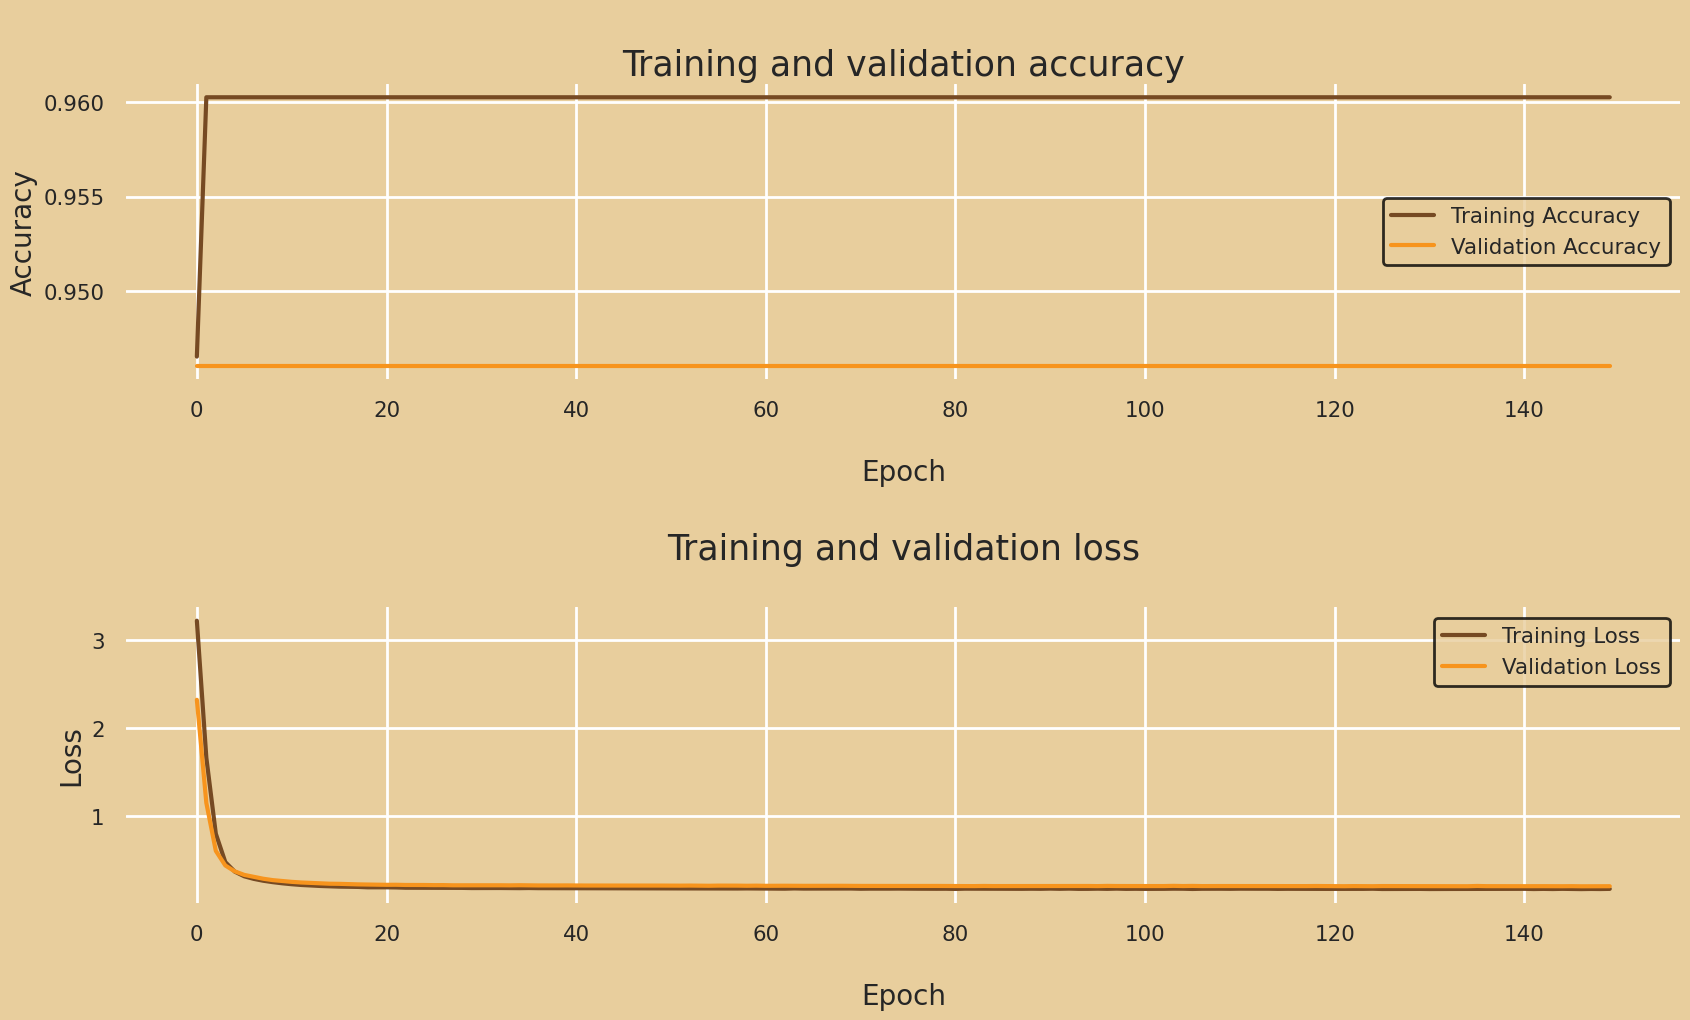

In [ ]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(len(acc)) # number of epochs

plt.rcParams["axes.facecolor"] = "#E0F7FA"
plt.figure(figsize=(20, 12), facecolor="#E0F7FA")
plt.subplot(2,1,1)
plt.gca().set_facecolor("#E0F7FA")
plt.tight_layout(pad=8.0)

plt.plot(epochs, acc, palette[0], label= "Training Accuracy")
plt.plot(epochs, val_acc, palette[1], label= "Validation Accuracy")
plt.yscale("linear")
plt.title("\nTraining and validation accuracy",fontsize=25)
plt.xlabel("\nEpoch",fontsize=20)
plt.ylabel("Accuracy",fontsize=20)
plt.legend(edgecolor="black")

plt.subplot(2,1,2)
plt.gca().set_facecolor("#E0F7FA")
plt.plot(epochs, loss, palette[0], label= "Training Loss")
plt.plot(epochs, val_loss, palette[1], label= "Validation Loss")
plt.title("Training and validation loss\n",fontsize=25)
plt.xlabel("\nEpoch",fontsize=20)
plt.ylabel("Loss",fontsize=20)
plt.legend(edgecolor="black")

sns.despine(left=True, bottom=True)
plt.show()